# **Analysis of MAL Anime, Genres and Users**

# Research Question
How does the categorisation of anime into genres influence the formation of anime fan (user) communities?

- Can we form genre communities from the genre tags on MAL in order to formally categorise anime titles?

- What influence (if any) will this have on the formation of fan communities?

*Some things to Note*

- This analysis of the anime fan community is localised to the user behaviours of MAL and while this provides us with a very wide user dataset, it cannot be taken to represent the entiretiy of the anime fan community which can be found across various platforms online and ofline

- What MAL does provide us with is a space where anime data interacts and is influenced directly by user data

- Additionally, MAL does have data about literature work (manga, light novels etc) which many anime are based on and from which a large number of anime fans might be influenced to watch an anime. But for the sake of this initial analysis we will focus only on the anime data for now. Future work can take the influence of original works into account.



# ANALYSIS FLOW

- Network 1 (Genre Co-occurrence): Modularity & density
  - *Question: "Are genres naturally organized into communities?"*
  - Validates Phase 1 results

- Network 2 (Anime-Community): Size & homogeneity
  - *Question: "Do communities get distinct anime?"*
  - How anime distribute across communities
  - BRIDGE ANIME ANALYSIS: How many bridge anime per community?
  - Do bridge anime cluster or scatter?

- Network 3 (User-Community): Degree & engagement
  - *Question: "Do users follow community structure?"*
  -  User specialization patterns
  - Community engagement levels
  - BRIDGE ANIME IMPACT:
    - *Do users who watch bridge anime explore more communities?*
    - *Are bridge users different from pure users?*

- SYNTHESIS:
  - "Genre categorization → Community formation → Bridge anime → User behavior"
   
  - Key finding: Genre structure influences users, but bridge anime enable cross-community exploration

In [ ]:
#importing all the necessary libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import kagglehub
from pandas import read_csv, merge
import os
import itertools
from networkx.algorithms import community
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

In [ ]:
#import data from kaggle
# Download latest version
path = kagglehub.dataset_download("hernan4444/anime-recommendation-database-2020")

print("Path to dataset files:", path)

# load anime synopsis dataset from kaggle
animelist_synoposis = read_csv(os.path.join(path, "anime_with_synopsis.csv"))

Using Colab cache for faster access to the 'anime-recommendation-database-2020' dataset.
Path to dataset files: /kaggle/input/anime-recommendation-database-2020


# Network 1 Analysis - Genre Co-ocurrence


In [ ]:
#Step 1: Cleaning and analysing anime dataset

In [ ]:
animelist_synoposis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16214 entries, 0 to 16213
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   MAL_ID     16214 non-null  int64 
 1   Name       16214 non-null  object
 2   Score      16214 non-null  object
 3   Genres     16214 non-null  object
 4   sypnopsis  16206 non-null  object
dtypes: int64(1), object(4)
memory usage: 633.5+ KB


In [ ]:
animelist_synoposis.head()

,MAL_ID,Name,Score,Genres,sypnopsis
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ..."
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen","Vash the Stampede is the man with a $$60,000,0..."
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",ches are individuals with special powers like ...
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",It is the dark century and the people are suff...


In [ ]:
# drop synopsis column (because we are not working with that for now)
animelist_synoposis = animelist_synoposis.drop(columns=["sypnopsis"])
animelist_synoposis.head()

,MAL_ID,Name,Score,Genres
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space"
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space"
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen"
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ..."
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural"


### *Some things to note:*

On MAL anime is described by three categories: genre, theme and demographic.

Looking at the site now there are:

*   18 Genres
*   52 Themes
*   5 Demographics

Not all anime have tags from all three categories

In the dataset we have, all three categories have been grouped together in the column genre, with other theme tags added which do not show up on the current version of the site.

For the sake of this analysis we should just work with the genres the way they have been organised in the dataset.

---

### *Next question: How many unique genre tags appear in the dataset?*

From this we can see which are the most common genre tags from our dataset and maybe we could even use this to make a word map.




In [ ]:
# Lets see how many unique tags are used in the genre groupings of the dataset
anime_genres = animelist_synoposis[["Genres"]]
unique_genres = []
for idx, row in anime_genres.iterrows():
  genres = row["Genres"].split(",")
  for g in genres:
    if g.strip() not in unique_genres:
      unique_genres.append(g.strip())

print("Number of unique genres:", len(unique_genres))
print("Unique genres:", unique_genres)

Number of unique genres: 42
Unique genres: ['Action', 'Adventure', 'Comedy', 'Drama', 'Sci-Fi', 'Space', 'Mystery', 'Shounen', 'Police', 'Supernatural', 'Magic', 'Fantasy', 'Sports', 'Josei', 'Romance', 'Slice of Life', 'Cars', 'Seinen', 'Horror', 'Psychological', 'Thriller', 'Super Power', 'Martial Arts', 'School', 'Ecchi', 'Vampire', 'Military', 'Historical', 'Dementia', 'Mecha', 'Demons', 'Samurai', 'Game', 'Shoujo', 'Harem', 'Music', 'Shoujo Ai', 'Shounen Ai', 'Kids', 'Parody', 'Yaoi', 'Unknown']


In [ ]:
# Now let's see how many anime fall under each genre
genre_count = {}
for idx, row in anime_genres.iterrows():
  genres = row["Genres"].split(",")
  for g in genres:
    if g.strip() not in genre_count:
      genre_count[g.strip()] = 1
    else:
      genre_count[g.strip()] += 1
print("Number of unique genres:", len(genre_count))
print("Number of anime per genre:", genre_count)
print("Most common genre:", max(genre_count, key=genre_count.get))

Number of unique genres: 42
Number of anime per genre: {'Action': 3846, 'Adventure': 2942, 'Comedy': 5975, 'Drama': 2589, 'Sci-Fi': 2551, 'Space': 491, 'Mystery': 721, 'Shounen': 2003, 'Police': 243, 'Supernatural': 1410, 'Magic': 1056, 'Fantasy': 3202, 'Sports': 708, 'Josei': 96, 'Romance': 1852, 'Slice of Life': 1912, 'Cars': 133, 'Seinen': 830, 'Horror': 430, 'Psychological': 340, 'Thriller': 130, 'Super Power': 627, 'Martial Arts': 416, 'School': 1577, 'Ecchi': 767, 'Vampire': 133, 'Military': 572, 'Historical': 1129, 'Dementia': 510, 'Mecha': 1094, 'Demons': 434, 'Samurai': 202, 'Game': 386, 'Shoujo': 688, 'Harem': 357, 'Music': 2241, 'Shoujo Ai': 79, 'Shounen Ai': 100, 'Kids': 2665, 'Parody': 649, 'Yaoi': 31, 'Unknown': 63}
Most common genre: Comedy


In [ ]:
#Step 2: Creating the genre co-occurance graph
#Because we want to look at the relationship between genres this graph will not include the Uknown genre
#As it is disconnected from the rest of the network

### Task Assigned to Copilot
Populate a graph named `Genres` with nodes representing unique anime genres and weighted edges connecting genres that appear together in the same anime, where the weight of an edge indicates the frequency of their co-occurrence.

In [ ]:
Genres = nx.Graph()
for idx, row in anime_genres.iterrows():
    genres = [g.strip() for g in row["Genres"].split(",") if g.strip()]

    # Add edges between co-occurring genres
    # itertools.combinations finds all the possible combinations in a container based on a given number
    # in our case we want all the possible pairs to make the edges
    for g1, g2 in itertools.combinations(genres, 2):
        if Genres.has_edge(g1, g2):
            Genres[g1][g2]["weight"] += 1
        else:
          # lets also add the frequency of each genre as a node attribute
            Genres.add_nodes_from([(g1, {"frequency": genre_count[g1]}), (g2, {"frequency": genre_count[g2]})])
            Genres.add_edge(g1, g2, weight=1)

print("Graph population complete. Number of nodes:", Genres.number_of_nodes())
print("The graph nodes are:", list(Genres.nodes()))
print("Number of edges:", Genres.number_of_edges())
print("Top ten strongest edges:", sorted(Genres.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:10])
print("Top ten weakest edges:", sorted(Genres.edges(data=True), key=lambda x: x[2]["weight"], reverse=False)[:10])
print("Node with the highest number of edges:", max(Genres.degree, key=lambda x: x[1])[0], "with number of edges:", max(Genres.degree, key=lambda x: x[1])[1])
print("Node with the highest frequency:", max(Genres.nodes.data(), key=lambda x: x[1]["frequency"])[0], "with a count of:", max(Genres.nodes.data(), key=lambda x: x[1]["frequency"])[1]["frequency"])

Graph population complete. Number of nodes: 41
The graph nodes are: ['Action', 'Adventure', 'Comedy', 'Drama', 'Sci-Fi', 'Space', 'Mystery', 'Shounen', 'Police', 'Supernatural', 'Magic', 'Fantasy', 'Sports', 'Josei', 'Romance', 'Slice of Life', 'Cars', 'Seinen', 'Horror', 'Psychological', 'Thriller', 'Super Power', 'Martial Arts', 'School', 'Ecchi', 'Vampire', 'Military', 'Historical', 'Dementia', 'Mecha', 'Demons', 'Samurai', 'Game', 'Shoujo', 'Harem', 'Music', 'Shoujo Ai', 'Shounen Ai', 'Kids', 'Parody', 'Yaoi']
Number of edges: 726
Top ten strongest edges: [('Action', 'Sci-Fi', {'weight': 1294}), ('Adventure', 'Fantasy', {'weight': 1269}), ('Action', 'Adventure', {'weight': 1252}), ('Action', 'Fantasy', {'weight': 1139}), ('Action', 'Comedy', {'weight': 1110}), ('Adventure', 'Comedy', {'weight': 1085}), ('Comedy', 'Shounen', {'weight': 1085}), ('Comedy', 'Fantasy', {'weight': 1083}), ('Comedy', 'Slice of Life', {'weight': 1034}), ('Comedy', 'School', {'weight': 944})]
Top ten weakes

So we can see some interesting trends from this graph showing the relationship between genres:



*   "Action" appears to be the genre connected to the most other genres with 40 edges connected to it
*   "Action" and "Sci-Fi" appear the most times together with a weight of 1294 correlating to the number of anime which feature in both genres
*   While "Comedy" is the most common genre with 5975 anime
*   There are several genre pairs with the lowest weight of 1



In [ ]:
#Step 3: Find communities in genre network then calculate modularity and density

## *Choosing the right clustering algorithm*

For this analysis we experimented with two different clustering algorithms available with netowrkx and python - the greedy algortim and the lauvain algorithm. Both of them performed very similarly, with low modularity due to the close relation of all the genres in the network.

\begin{array}{ccc}
Metric&Greedy&Louvain \\
Modularity Score&0.1199&0.1223 \\
NumberOfCommunities&4&4   
\end{array}

Both algorithms found very similar clusters:

- Action & Adventure
- Romance & Slice of Life
- Dark & Psychological
- Niche

These communities provide containers that are general enough to find some distictions between the genres even though ultimatly all the genres are very interconnected.

In the end we chose to go with the louvain algorithm because the genres were distributed better across all the communities and did not leave weird outliers in one community instead of another, as was the case with the greedy algorithm (like having josei in dark & psychological instead of romance & slice of life).

## Louvain Algorithm

It uses the louvain method described in Fast unfolding of communities in large networks, Vincent D Blondel, Jean-Loup Guillaume, Renaud Lambiotte, Renaud Lefebvre, Journal of Statistical Mechanics: Theory and Experiment 2008(10), P10008 (12pp)

Source: https://python-louvain.readthedocs.io/en/latest/

From copilot:

WHAT IS THE LOUVAIN ALGORITHM?

The Louvain method is one of the most popular algorithms for community detection
because it's fast AND produces very high quality results.

KEY DIFFERENCE FROM GREEDY MODULARITY:
- Greedy Modularity: Merges communities from bottom-up
- Louvain: Uses a MULTI-LEVEL approach with optimization

HOW LOUVAIN WORKS (Simplified):

The algorithm has TWO PHASES that repeat until no improvement:

PHASE 1: LOCAL OPTIMIZATION
- For each node, try moving it to neighboring communities
- Move the node if it INCREASES modularity
- Repeat for all nodes until no more moves increase modularity
- Result: Communities start forming locally

PHASE 2: AGGREGATION (Pooling)
- Treat each community as a single "super-node"
- Create a new network where super-nodes are the new nodes
- Connect super-nodes if their original communities connected
- Go back to PHASE 1 on this new network

WHY IS THIS BETTER?
- It finds local optima efficiently
- The multi-level approach helps avoid getting stuck
- Can detect communities at different scales
- Often produces higher modularity than greedy methods

ANALOGY:

Think of it like organizing a messy room:
1. First pass: Move items into rough areas (Local Optimization)
2. Reorganize: Group the rough areas into sections (Aggregation)
3. Refine: Move items between sections if it improves organization
4. Repeat steps 1-3 until the room looks good

In [ ]:
pip install python-louvain


NETWORK 1 - GENRE CO-OCCURRENCE NETWORK ANALYSIS

[STEP 1] Running Louvain Algorithm...
----------------------------------------------------------------------
✓ Algorithm completed in 0.01 seconds
✓ Found 4 communities

[STEP 2] Calculating Modularity
----------------------------------------------------------------------

✓ Modularity Score: 0.1223

What this means:
  • Modularity ranges from 0 to 1
  • Measures how well-separated communities are
  • >0.4 typically indicates strong community structure

Verdict: WEAK ⚠️
Detail: Communities are not well-separated.

[STEP 3] Basic Network Statistics
----------------------------------------------------------------------
Total genres (nodes):     41
Total connections (edges): 726
Number of communities:    4

[STEP 4] Within-Community Density
----------------------------------------------------------------------

How tightly connected is each community?
(Higher = genres in same community co-occur frequently)
--------------------------------

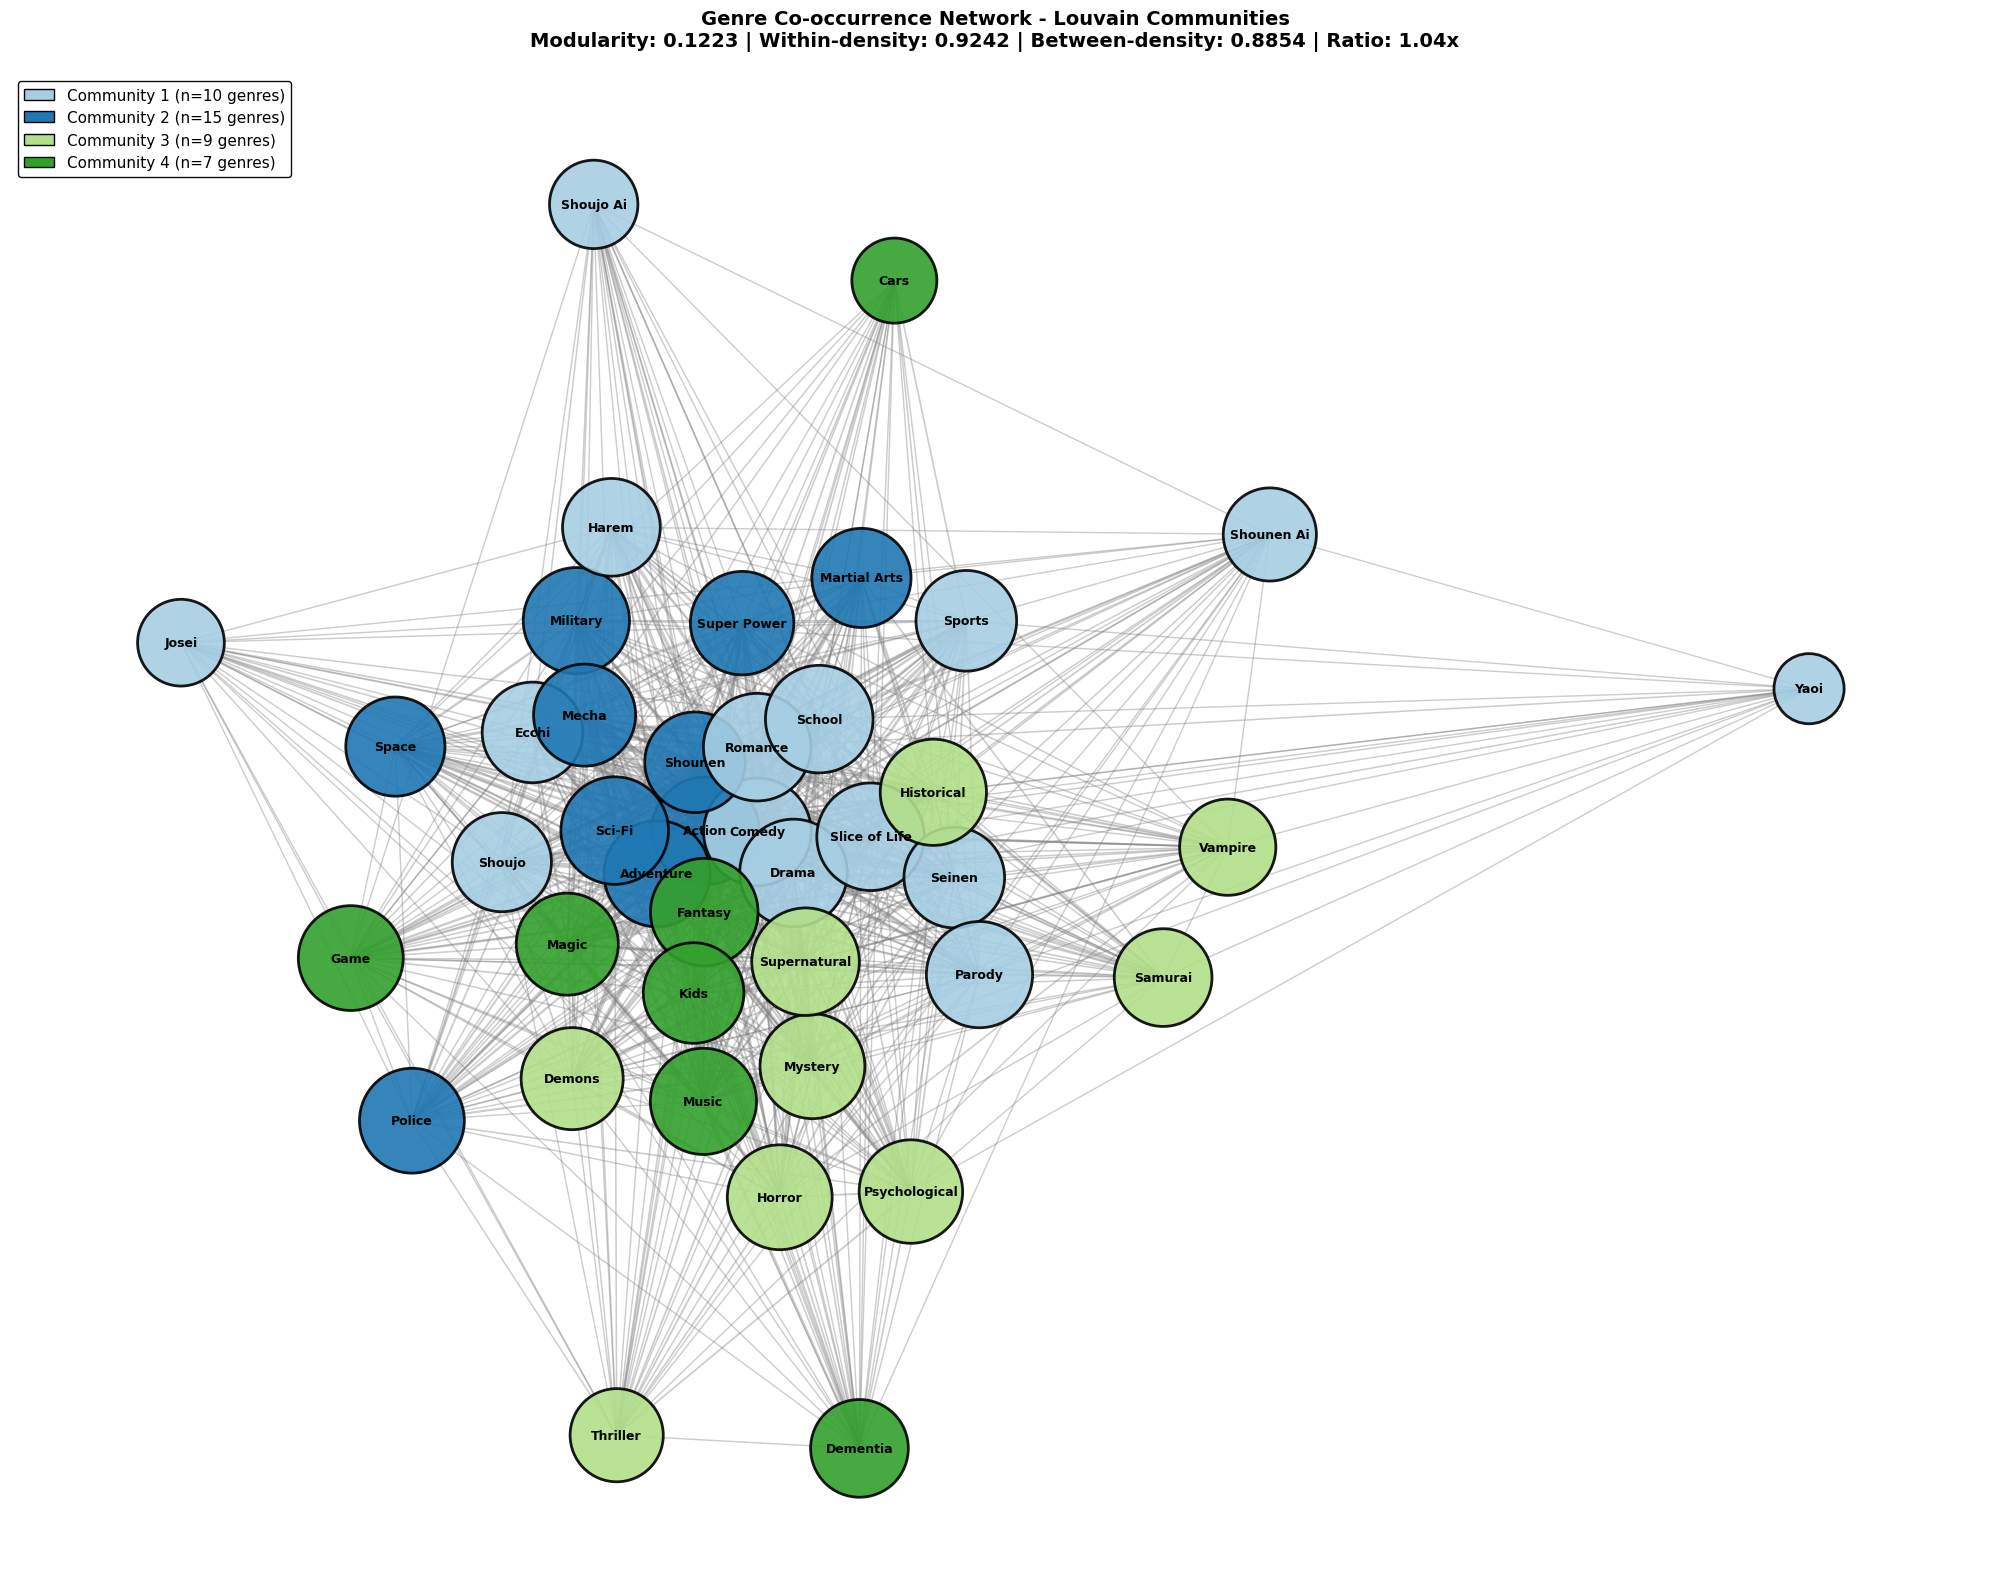


✓ NETWORK 1 ANALYSIS COMPLETE!

Results saved for Phase 3 Synthesis


In [ ]:
# ============================================================================
# NETWORK 1 - GENRE CO-OCCURRENCE NETWORK ANALYSIS
# ============================================================================

"""
NETWORK 1 OVERVIEW:
---------------------------
Goal: Analyze the genre co-occurrence network to answer:
"Are genres naturally organized into communities?"

This script:
1. Runs Louvain algorithm on the pre-built genre network
2. Extracts and validates communities
3. Calculates modularity and density measures
4. Visualizes the network with communities
5. Provides interpretation of findings
"""

def analyze_louvain_and_calculate_measures(graph):
    """
    Run Louvain algorithm and calculate network measures
    """
    try:
        from community import community_louvain
    except ImportError:
        print("\n" + "!"*70)
        print("ERROR: python-louvain package not installed")
        print("!"*70)
        print("\nTo install, run:")
        print("  pip install python-louvain")
        print("!"*70)
        return None

    print("\n" + "="*70)
    print("NETWORK 1 - GENRE CO-OCCURRENCE NETWORK ANALYSIS")
    print("="*70)

    # =========================================================================
    # STEP 1: RUN LOUVAIN ALGORITHM
    # =========================================================================

    print("\n[STEP 1] Running Louvain Algorithm...")
    print("-" * 70)

    import time
    start_time = time.time()

    # Run Louvain with fixed seed for reproducibility
    partition = community_louvain.best_partition(
        graph,
        weight='weight',
        randomize=None,
        random_state=42
    )

    elapsed_time = time.time() - start_time

    # Convert partition to communities list
    communities_dict = defaultdict(list)
    for node, community_id in partition.items():
        communities_dict[community_id].append(node)

    communities_list = list(communities_dict.values())

    print(f"✓ Algorithm completed in {elapsed_time:.2f} seconds")
    print(f"✓ Found {len(communities_list)} communities")

    # =========================================================================
    # STEP 2: CALCULATE MODULARITY SCORE
    # =========================================================================

    print("\n[STEP 2] Calculating Modularity")
    print("-" * 70)

    # Calculate modularity using the community_louvain module
    modularity_score = community_louvain.modularity(
        partition,
        graph,
        weight='weight'
    )

    print(f"\n✓ Modularity Score: {modularity_score:.4f}")
    print(f"\nWhat this means:")
    print(f"  • Modularity ranges from 0 to 1")
    print(f"  • Measures how well-separated communities are")
    print(f"  • >0.4 typically indicates strong community structure")

    if modularity_score > 0.4:
        interpretation = "STRONG ✅"
        detail = "Genres are well-organized into distinct communities."
    elif modularity_score > 0.3:
        interpretation = "MODERATE ✓"
        detail = "Communities exist but with some overlap."
    else:
        interpretation = "WEAK ⚠️"
        detail = "Communities are not well-separated."

    print(f"\nVerdict: {interpretation}")
    print(f"Detail: {detail}")

    # =========================================================================
    # STEP 3: DISPLAY BASIC STATISTICS
    # =========================================================================

    print("\n[STEP 3] Basic Network Statistics")
    print("-" * 70)
    print(f"Total genres (nodes):     {graph.number_of_nodes()}")
    print(f"Total connections (edges): {graph.number_of_edges()}")
    print(f"Number of communities:    {len(communities_list)}")

    # =========================================================================
    # STEP 4: CALCULATE WITHIN-COMMUNITY DENSITY
    # =========================================================================

    print("\n[STEP 4] Within-Community Density")
    print("-" * 70)
    print(f"\nHow tightly connected is each community?")
    print(f"(Higher = genres in same community co-occur frequently)")
    print(f"{'-'*70}")

    within_densities = []
    community_info = []

    # Sort communities by size for clearer presentation
    sorted_communities = sorted(
        enumerate(communities_list),
        key=lambda x: len(x[1]),
        reverse=True
    )

    for idx, community_set in sorted_communities:
        community_size = len(community_set)

        # Calculate internal edges (edges within the community)
        internal_edges = 0
        for node1 in community_set:
            for node2 in community_set:
                if node1 < node2 and graph.has_edge(node1, node2):
                    internal_edges += 1

        # Calculate external edges (edges going outside the community)
        external_edges = 0
        for node in community_set:
            for neighbor in graph.neighbors(node):
                if neighbor not in community_set:
                    external_edges += 1

        # Calculate density
        # Density = actual edges / possible edges
        max_possible_edges = community_size * (community_size - 1) / 2
        density = internal_edges / max_possible_edges if community_size > 1 else 0

        within_densities.append(density)

        # SEMANTIC MEANING: What does this density tell us?
        if density > 0.5:
            density_interpretation = "High - genres co-occur frequently ✅"
        elif density > 0.3:
            density_interpretation = "Moderate - some co-occurrence"
        else:
            density_interpretation = "Low - genres rarely co-occur"

        print(f"\n🎬 Community {idx + 1}: ({community_size} genres)")
        print(f"   Genres: {', '.join(sorted(community_set))}")
        print(f"   Internal edges: {internal_edges}")
        print(f"   External edges: {external_edges}")
        print(f"   Density: {density:.4f} → {density_interpretation}")

        community_info.append({
            'id': idx,
            'size': community_size,
            'genres': sorted(community_set),
            'internal_edges': internal_edges,
            'external_edges': external_edges,
            'density': density
        })

    # Calculate average within-community density
    avg_within = np.mean(within_densities)
    print(f"\n{'='*70}")
    print(f"Average Within-Community Density: {avg_within:.4f}")
    print(f"{'='*70}")

    # =========================================================================
    # STEP 5: CALCULATE BETWEEN-COMMUNITY DENSITY
    # =========================================================================

    print("\n[STEP 5] Between-Community Density")
    print("-" * 70)
    print(f"\nHow much do different communities mix?")
    print(f"(Lower = communities are well-separated)")
    print(f"{'-'*70}")

    between_densities = {}

    # Sort communities for pairing
    sorted_communities_list = [c[1] for c in sorted_communities]

    for i in range(len(sorted_communities_list)):
        for j in range(i+1, len(sorted_communities_list)):
            community_i = sorted_communities_list[i]
            community_j = sorted_communities_list[j]

            # Count edges between the two communities
            edges_between = 0
            for node1 in community_i:
                for node2 in community_j:
                    if graph.has_edge(node1, node2):
                        edges_between += 1

            # Possible edges between communities
            max_possible_between = len(community_i) * len(community_j)

            # Calculate density
            density_between = edges_between / max_possible_between if max_possible_between > 0 else 0

            between_densities[(i+1, j+1)] = density_between

            # SEMANTIC MEANING: What does this tell us about community separation?
            if density_between < 0.05:
                separation = "Well-separated ✅"
            elif density_between < 0.1:
                separation = "Mostly separated"
            else:
                separation = "Significant mixing"

            print(f"\nCommunity {i+1} ↔ Community {j+1}")
            print(f"   Edges between: {edges_between}")
            print(f"   Density: {density_between:.4f} → {separation}")

    # Calculate average between-community density
    avg_between = np.mean(list(between_densities.values())) if between_densities else 0
    print(f"\n{'='*70}")
    print(f"Average Between-Community Density: {avg_between:.4f}")
    print(f"{'='*70}")

    # =========================================================================
    # STEP 6: DENSITY RATIO ANALYSIS
    # =========================================================================

    print("\n[STEP 6] Within vs Between Density Analysis")
    print("-" * 70)

    ratio = avg_within / avg_between if avg_between > 0 else float('inf')

    print(f"\nWithin-to-Between Density Ratio: {ratio:.2f}x")
    print(f"\nWhat this means:")
    print(f"  • Higher ratio = better community separation")
    print(f"  • Shows how much tighter within-community connections are")

    if ratio > 5:
        print(f"  → Excellent separation ✅")
    elif ratio > 2:
        print(f"  → Good separation ✓")
    else:
        print(f"  → Weak separation ⚠️")

    # =========================================================================
    # STEP 7: CONNECTIVITY AND COHESION
    # =========================================================================

    print("\n[STEP 7] Network Cohesion Measures")
    print("-" * 70)

    # Average degree
    degrees = [graph.degree(n) for n in graph.nodes()]
    avg_degree = np.mean(degrees)

    print(f"\nAverage genre degree: {avg_degree:.2f}")
    print(f"  → On average, each genre connects to {avg_degree:.1f} other genres")

    # Network clustering
    avg_clustering = nx.average_clustering(graph)
    print(f"\nAverage clustering coefficient: {avg_clustering:.4f}")
    print(f"  → Measures how likely neighbors are also neighbors")

    if avg_clustering > 0.3:
        print(f"  → Strong clustering: tight genre patterns ✅")
    else:
        print(f"  → Moderate clustering")

    # Network components
    num_components = nx.number_connected_components(graph)
    print(f"\nNetwork components: {num_components}")
    if num_components == 1:
        print(f"  → Network is fully connected ✅")
    else:
        print(f"  → Network has {num_components} disconnected parts")

    # =========================================================================
    # STEP 8: FINAL SUMMARY AND INTERPRETATION
    # =========================================================================

    print("\n[STEP 8] Final Summary")
    print("="*70)

    # Aggregate evidence
    evidence_score = 0

    # Evidence 1: Modularity
    if modularity_score > 0.4:
        evidence_score += 3
        mod_evidence = "✅ Strong modularity (>0.4)"
    elif modularity_score > 0.3:
        evidence_score += 2
        mod_evidence = "✓ Moderate modularity (0.3-0.4)"
    else:
        evidence_score += 1
        mod_evidence = "⚠️ Weak modularity (<0.3)"

    # Evidence 2: Density ratio
    if ratio > 5:
        evidence_score += 3
        density_evidence = "✅ Excellent within/between separation (ratio >5)"
    elif ratio > 2:
        evidence_score += 2
        density_evidence = "✓ Good within/between separation (ratio >2)"
    else:
        evidence_score += 1
        density_evidence = "⚠️ Weak within/between separation (ratio <2)"

    # Evidence 3: Clustering
    if avg_clustering > 0.3:
        evidence_score += 2
        cluster_evidence = "✓ Strong clustering patterns"
    else:
        evidence_score += 1
        cluster_evidence = "⚠️ Moderate clustering"

    print(f"\nEvidence Summary:")
    print(f"  1. {mod_evidence}")
    print(f"  2. {density_evidence}")
    print(f"  3. {cluster_evidence}")

    print(f"\nTotal Evidence Score: {evidence_score}/8")
    print(f"\n{'='*70}")

    # Final answer
    if evidence_score >= 7:
        answer = "YES - STRONG EVIDENCE ✅✅✅"
        conclusion = "Genres are strongly organized into natural communities.\n" \
                    "The communities are well-separated and internally cohesive."
    elif evidence_score >= 5:
        answer = "YES - MODERATE EVIDENCE ✓✓"
        conclusion = "Genres show community organization with some overlap.\n" \
                    "Communities are distinguishable but not completely separate."
    else:
        answer = "WEAK EVIDENCE ⚠️"
        conclusion = "Genres do not show clear community organization.\n" \
                    "Communities are not well-separated."

    print(f"RESEARCH QUESTION: Are genres naturally organized into communities?")
    print(f"ANSWER: {answer}")
    print(f"CONCLUSION: {conclusion}")
    print(f"{'='*70}\n")

    # =========================================================================
    # RETURN ALL RESULTS
    # =========================================================================

    return {
        'partition': partition,
        'communities': communities_list,
        'modularity': modularity_score,
        'within_densities': within_densities,
        'between_densities': between_densities,
        'avg_within': avg_within,
        'avg_between': avg_between,
        'ratio': ratio,
        'community_info': community_info,
        'avg_degree': avg_degree,
        'avg_clustering': avg_clustering,
        'time': elapsed_time
    }


def visualize_louvain_communities(graph, partition, results):
    """
    Visualize the Louvain communities with enhanced information and visible edges
    """
    print("\n[STEP 9] Creating Visualization...")
    print("-" * 70)

    # Convert partition to communities
    communities_dict = defaultdict(list)
    for node, community_id in partition.items():
        communities_dict[community_id].append(node)

    communities_list = list(communities_dict.values())

    # Create colors for communities
    colors = plt.cm.Paired(range(len(communities_list)))

    # Map nodes to community colors
    node_to_community = {node: idx for idx, (_, nodes) in enumerate(sorted(
        communities_dict.items(),
        key=lambda x: len(x[1]),
        reverse=True
    )) for node in nodes}

    node_colors = [colors[node_to_community[node]] for node in graph.nodes()]

    # Create plot with larger figure size for better visibility
    fig, ax = plt.subplots(figsize=(20, 16))

    # Layout
    pos = nx.spring_layout(graph, k=2.5, iterations=100, seed=42, weight='weight')

    # ─────────────────────────────────────────────────────────────────
    # DRAW EDGES (THICKER AND MORE VISIBLE)
    # ─────────────────────────────────────────────────────────────────

    edges = graph.edges()
    weights = [graph[u][v]['weight'] for u, v in edges]

    if weights:
        max_weight = max(weights)
        min_weight = min(weights)

        # Normalize weights to thicker line widths (1 to 8)
        # This makes edges much more visible
        normalized_weights = [
            1 + (w - min_weight) / (max_weight - min_weight) * 7
            for w in weights
        ]
    else:
        normalized_weights = [1] * len(edges)

    # Draw edges with thicker lines and higher alpha for visibility
    nx.draw_networkx_edges(
        graph, pos,
        width=normalized_weights,
        alpha=0.4,  # Increased from 0.2 for better visibility
        ax=ax,
        edge_color='gray'
    )

    # ─────────────────────────────────────────────────────────────────
    # DRAW NODES
    # ─────────────────────────────────────────────────────────────────

    # Size nodes based on their degree (connectivity)
    node_sizes = [graph.degree(node) * 150 for node in graph.nodes()]

    nx.draw_networkx_nodes(
        graph, pos,
        node_color=node_colors,
        node_size=node_sizes,
        ax=ax,
        alpha=0.9,
        edgecolors='black',
        linewidths=2
    )

    # ─────────────────────────────────────────────────────────────────
    # DRAW LABELS
    # ─────────────────────────────────────────────────────────────────

    nx.draw_networkx_labels(
        graph, pos,
        font_size=9,
        font_weight='bold',
        ax=ax,
        font_color='black'
    )

    # ─────────────────────────────────────────────────────────────────
    # TITLE
    # ─────────────────────────────────────────────────────────────────

    title = f'Genre Co-occurrence Network - Louvain Communities\n' \
            f'Modularity: {results["modularity"]:.4f} | ' \
            f'Within-density: {results["avg_within"]:.4f} | ' \
            f'Between-density: {results["avg_between"]:.4f} | ' \
            f'Ratio: {results["ratio"]:.2f}x'

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')

    # ─────────────────────────────────────────────────────────────────
    # LEGEND
    # ─────────────────────────────────────────────────────────────────

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors[i], edgecolor='black', label=f'Community {i+1} (n={len(communities_list[i])} genres)')
        for i in range(len(communities_list))
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper left',
        fontsize=11,
        framealpha=0.95,
        edgecolor='black'
    )

    plt.tight_layout()
    plt.savefig('network1_genre_communities.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ Visualization saved as 'network1_genre_communities.png'")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

# Run the analysis
network1_results = analyze_louvain_and_calculate_measures(Genres)

# Visualize
visualize_louvain_communities(Genres, network1_results['partition'], network1_results)

print("\n" + "="*70)
print("✓ NETWORK 1 ANALYSIS COMPLETE!")
print("="*70)
print("\nResults saved for Phase 3 Synthesis")

### *Network 1 Reflections*

While these results may not necessarily support to choice to cluster the anime genres in to communities - due to the very low modularity - it is help us better understand the nature of the genres within the context of anime, namely that they are highly interconnected. This obviously makes a lot of sense since it is very rare that a single anime story could be desribed in only one way. What this tells us is that the genre thematic qualities are similar across the whole anime network.

What we can maybe start to predict from this is that this will then also reflect into the formation of user communities - while yes users could most likely gravitate to one general genre community more than the other, it may be unlikely that we will see a lot of users in only one community.

# Network 2 Analysis - Bipartite Anime - Genre Communities

In [ ]:
#Step 1: Mapping anime to genre communities

Now that we have found our communities, based on the lauvain algorithm, we can associate each anime in our dataset to a corresponding community.

How the mapping will work is that we will go through the the genres of each anime and count how many of the genre belong to each community, the community with the highest count will be assigned that anime. Anime which have an equal distribution of genres in multiple communities will be considered "bridge anime" and will be assigned to all the communities they belong to.

Doing this will help to better define and understand the overlap between the genre communities, because the genres only really make sense in the context of the anime.

In [ ]:
# ============================================================================
# NETWORK 2 (STEP 1): ASSIGNING ANIME TO GENRE COMMUNITIES
# ============================================================================

"""
NETWORK 2 (STEP 1):
-----------------
Goal: Map each anime to the most appropriate genre community

For each anime:
1. Extract its genres
2. Count how many genres belong to each community
3. Check if distribution is EQUAL across communities
   - If equal: anime is a bridge (assigned to multiple communities)
   - If not equal: assign to community with most genres
4. Calculate confidence score
5. Handle multi-community assignments
"""

def create_genre_to_community_mapping(louvain_communities):
    """
    [STEP 1] Create a lookup dictionary: genre -> community_id

    This makes it fast to look up which community a genre belongs to.

    Input: List of communities (each community is a list of genres)
    Output: Dictionary mapping each genre to its community ID
    """
    print("\n" + "="*70)
    print("NETWORK 2 (STEP 1): ASSIGNING ANIME TO GENRE COMMUNITIES")
    print("="*70)

    print("\n[STEP 1] Creating Genre-to-Community Mapping...")
    print("-" * 70)

    genre_to_community = {}

    # For each community, map all its genres to the community ID
    for community_id, community_genres in enumerate(louvain_communities, 1):
        for genre in community_genres:
            genre_to_community[genre] = community_id

    print(f"\n✓ Mapping created for {len(genre_to_community)} genres")
    print(f"✓ Total communities: {len(louvain_communities)}")

    # Display the mapping
    print("\nGenre to Community Mapping:")
    for community_id, community_genres in enumerate(louvain_communities, 1):
        print(f"\n  Community {community_id}: ({len(community_genres)} genres)")
        print(f"    {', '.join(sorted(community_genres))}")

    return genre_to_community, louvain_communities


def assign_anime_to_communities(anime_df, genre_to_community, louvain_communities):
    """
    [STEP 2] Assign each anime to its best-matching community

    For each anime:
    - Extract its genres
    - Count how many genres belong to each community
    - Check if distribution is EQUAL across all communities
    - If equal: assign to all those communities (bridge anime)
    - If not equal: assign to the community with most genres
    - Calculate confidence (% of genres in assigned communities)
    """
    print("\n[STEP 2] Assigning Anime to Communities...")
    print("-" * 70)

    # Initialize lists to store results
    anime_assignments = []

    # Process each anime
    total_anime = len(anime_df)
    print(f"\nProcessing {total_anime} anime...")

    for idx, row in anime_df.iterrows():
        # Extract genres from the anime
        # Handle different possible column names and formats
        if 'Genres' in row:
            genres_str = row['Genres']
        elif 'genre' in row:
            genres_str = row['genre']
        else:
            continue

        # Skip if no genres listed
        if pd.isna(genres_str):
            continue

        # Parse genres (assuming they're comma-separated)
        genres = [g.strip() for g in str(genres_str).split(',') if g.strip()]

        if not genres:
            continue

        # [STEP 2A] Count genres in each community
        community_counts = defaultdict(int)
        for genre in genres:
            if genre in genre_to_community:
                community_id = genre_to_community[genre]
                community_counts[community_id] += 1

        # [STEP 2B] Check if distribution is equal across communities
        if community_counts:
            # Check if all communities have equal genre counts
            counts_list = list(community_counts.values())
            is_equal_distribution = len(set(counts_list)) == 1 and len(community_counts) > 1

            if is_equal_distribution:
                # Equal distribution: assign to all communities (true bridge)
                assigned_communities = sorted(list(community_counts.keys()))
                count_in_community = community_counts[assigned_communities[0]]
                confidence = count_in_community / len(genres)

                # Create a single record for the bridge anime with all assigned communities
                anime_assignments.append({
                    'anime_id': row["MAL_ID"],
                    'anime_name': row.get('Name', row.get('name', f'Anime_{idx}')),
                    'genres': ', '.join(genres),
                    'num_genres': len(genres),
                    'assigned_communities': assigned_communities,
                    'confidence': confidence,
                    'communities_spanned': len(community_counts),
                    'is_bridge': True,
                    'community_distribution': dict(community_counts)
                })
            else:
                # Unequal distribution: assign to community with most genres
                assigned_community = max(community_counts, key=community_counts.get)
                count_in_community = community_counts[assigned_community]

                # [STEP 2C] Calculate confidence score
                # Confidence = (genres in assigned community) / (total genres)
                confidence = count_in_community / len(genres)

                # [STEP 2D] Count how many communities this anime spans
                num_communities_spanned = len(community_counts)

                # [STEP 2E] Identify if anime is a "bridge" (equal distribution only)
                is_bridge = False

                # Store the assignment
                anime_assignments.append({
                    'anime_id': row["MAL_ID"],
                    'anime_name': row.get('Name', row.get('name', f'Anime_{idx}')),
                    'genres': ', '.join(genres),
                    'num_genres': len(genres),
                    'assigned_communities': [assigned_community],
                    'confidence': confidence,
                    'communities_spanned': num_communities_spanned,
                    'is_bridge': is_bridge,
                    'community_distribution': dict(community_counts)
                })

        # Progress indicator
        if (idx + 1) % max(1, total_anime // 10) == 0:
            print(f"  Processed {idx + 1}/{total_anime} anime...")

    # Create DataFrame from assignments
    assignments_df = pd.DataFrame(anime_assignments)

    print(f"\n✓ Assignment complete!")
    print(f"  Total anime assigned: {len(assignments_df)}")

    return assignments_df


def analyze_assignments(assignments_df, louvain_communities):
    """
    [STEP 3] Analyze the anime assignments

    Show statistics about:
    - How many anime in each community
    - Confidence scores (how well anime match their communities)
    - Bridge anime (anime spanning multiple communities with equal distribution)
    """
    print("\n[STEP 3] Assignment Statistics")
    print("-" * 70)

    # [STEP 3A] Count anime per community
    print("\nAnime per Community:")

    # Count unique anime per community (since bridges might span multiple)
    # Use range() to iterate through community indices
    for community_id in range(len(louvain_communities)):
        community_num = community_id + 1
        # Count anime that are assigned to this community
        anime_in_community = assignments_df[
            assignments_df['assigned_communities'].apply(lambda x: community_num in x)
        ]['anime_id'].nunique()

        percentage = (anime_in_community / assignments_df['anime_id'].nunique()) * 100
        num_genres = len(louvain_communities[community_id])
        print(f"\n  Community {community_num}: {anime_in_community} anime ({percentage:.1f}%)")
        print(f"    Contains {num_genres} genres: {', '.join(louvain_communities[community_id])}")

    # [STEP 3B] Confidence score statistics
    print("\n" + "-" * 70)
    print("Confidence Score Statistics:")
    print(f"  Mean confidence: {assignments_df['confidence'].mean():.4f}")
    print(f"  Median confidence: {assignments_df['confidence'].median():.4f}")
    print(f"  Min confidence: {assignments_df['confidence'].min():.4f}")
    print(f"  Max confidence: {assignments_df['confidence'].max():.4f}")

    # [STEP 3C] Bridge anime statistics
    print("\n" + "-" * 70)
    print("Bridge Anime (Equal Distribution Across Multiple Communities):")
    bridge_anime = assignments_df[assignments_df['is_bridge']]
    print(f"  Total bridge anime: {len(bridge_anime)} ({(len(bridge_anime)/len(assignments_df))*100:.1f}%)")

    # Show distribution of how many communities they span
    span_distribution = bridge_anime['communities_spanned'].value_counts().sort_index()
    for num_communities, count in span_distribution.items():
        print(f"    Spanning {num_communities} communities: {count} anime")

    # Show examples of bridge anime with all assigned communities
    if len(bridge_anime) > 0:
        print(f"\n  Examples of Bridge Anime:")
        for idx, row in bridge_anime.head(10).iterrows():
            print(f"    - {row['anime_name']}: {row['genres']}")
            print(f"      Assigned to Communities: {row['assigned_communities']}")
            print(f"      Distribution: {row['community_distribution']}")

    # [STEP 3D] Low confidence anime (might be misassigned)
    print("\n" + "-" * 70)
    print("Low Confidence Anime (confidence < 0.5):")
    low_conf = assignments_df[assignments_df['confidence'] < 0.5]
    print(f"  Total: {len(low_conf)} anime ({(len(low_conf)/len(assignments_df))*100:.1f}%)")

    if len(low_conf) > 0:
        print("\n  Examples:")
        for idx, row in low_conf.head(10).iterrows():
            print(f"    - {row['anime_name']}: {row['genres']}")
            print(f"      Assigned to Communities {row['assigned_communities']} (confidence: {row['confidence']:.2f})")


def create_summary_table(assignments_df, louvain_communities):
    """
    [STEP 4] Create a summary table

    Shows a clean table with all anime assignments
    """
    print("\n[STEP 4] Creating Summary Table")
    print("-" * 70)

    # Create community name mapping for readability
    community_names = {
        1: "Action & Adventure",
        2: "Romance & Slice of Life",
        3: "Dark & Psychological",
        4: "Niche & Fantasy"
    }

    # Add all community names for bridge anime
    assignments_df['all_community_names'] = assignments_df['assigned_communities'].apply(
        lambda x: ', '.join([community_names.get(c, f"Community {c}") for c in x])
    )

    # Create a display table
    display_df = assignments_df[[
        'anime_name',
        'num_genres',
        'all_community_names',
        'confidence',
        'is_bridge'
    ]].copy()

    display_df.columns = [
        'Anime Name',
        'Num Genres',
        'Assigned Communities',
        'Confidence',
        'Is Bridge'
    ]

    print(f"\nFirst 20 anime assignments:")
    print(display_df.head(20).to_string(index=False))

    print(f"\n... ({len(display_df)} total anime)")

    return assignments_df


def save_assignments(assignments_df, output_file='anime_community_assignments.csv'):
    """
    [STEP 5] Save assignments to CSV for later use

    This creates a file you can use in Phase 3 for user analysis
    """
    print("\n[STEP 5] Saving Results")
    print("-" * 70)

    # Prepare dataframe for saving (convert list to comma-separated string for CSV)
    save_df = assignments_df.copy()
    save_df['assigned_communities'] = save_df['assigned_communities'].apply(lambda x: ', '.join(map(str, x)))
    save_df['community_distribution'] = save_df['community_distribution'].apply(str)

    # Select only the columns we want to save
    save_df = save_df[[
        'anime_id',
        'anime_name',
        'genres',
        'num_genres',
        'assigned_communities',
        'all_community_names',
        'confidence',
        'is_bridge',
        'communities_spanned',
        'community_distribution'
    ]]

    # Save to CSV
    save_df.to_csv(output_file, index=False)
    print(f"\n✓ Assignments saved to: {output_file}")
    print(f"  Total records: {len(save_df)}")

    return assignments_df


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_phase2(anime_df, louvain_communities):
    """
    Run the complete Phase 2 pipeline

    Input:
    - anime_df: DataFrame with anime data (must have 'Genres' or 'genre' column)
    - louvain_communities: List of communities from Phase 1

    Output:
    - assignments_df: DataFrame with anime-to-community assignments
    """

    # Step 1: Create genre to community mapping
    genre_to_community, communities = create_genre_to_community_mapping(louvain_communities)

    # Step 2: Assign anime to communities
    assignments_df = assign_anime_to_communities(anime_df, genre_to_community, communities)

    # Step 3: Analyze assignments
    analyze_assignments(assignments_df, communities)

    # Step 4: Create summary table
    assignments_df = create_summary_table(assignments_df, communities)

    # Step 5: Save results
    assignments_df = save_assignments(assignments_df)

    print("\n" + "="*70)
    print("✓ Network 2 (STEP 1) COMPLETE!")
    print("="*70)

    return assignments_df

# Run Phase 2
animeGenreComs_df = run_phase2(animelist_synoposis, network1_results['communities'])


NETWORK 2 (STEP 1): ASSIGNING ANIME TO GENRE COMMUNITIES

[STEP 1] Creating Genre-to-Community Mapping...
----------------------------------------------------------------------

✓ Mapping created for 41 genres
✓ Total communities: 4

Genre to Community Mapping:

  Community 1: (10 genres)
    Action, Adventure, Martial Arts, Mecha, Military, Police, Sci-Fi, Shounen, Space, Super Power

  Community 2: (15 genres)
    Comedy, Drama, Ecchi, Harem, Josei, Parody, Romance, School, Seinen, Shoujo, Shoujo Ai, Shounen Ai, Slice of Life, Sports, Yaoi

  Community 3: (9 genres)
    Demons, Historical, Horror, Mystery, Psychological, Samurai, Supernatural, Thriller, Vampire

  Community 4: (7 genres)
    Cars, Dementia, Fantasy, Game, Kids, Magic, Music

[STEP 2] Assigning Anime to Communities...
----------------------------------------------------------------------

Processing 16214 anime...
  Processed 1621/16214 anime...
  Processed 3242/16214 anime...
  Processed 4863/16214 anime...
  Proces

In [ ]:
#Step 2: Construct bipartite anime - genre community network and analyse distribution


STARTING NETWORK 2 ANALYSIS

PHASE 3: NETWORK 2 - ANIME-COMMUNITY DISTRIBUTION ANALYSIS

[STEP 1] Loading Anime-Community Assignments from Phase 2 (Revised)
----------------------------------------------------------------------

✓ Loaded assignments DataFrame
  Total anime: 16151
  Columns: ['anime_id', 'anime_name', 'genres', 'num_genres', 'assigned_communities', 'confidence', 'communities_spanned', 'is_bridge', 'community_distribution', 'all_community_names']

Sample assignments:
                        anime_name assigned_communities  confidence  is_bridge
0                     Cowboy Bebop                  [1]    0.666667      False
1  Cowboy Bebop: Tengoku no Tobira                  [1]    0.600000      False
2                           Trigun                  [1]    0.666667      False
3               Witch Hunter Robin                  [1]    0.333333      False
4                   Bouken Ou Beet                  [1]    0.500000      False
5                     Eyeshield 21    

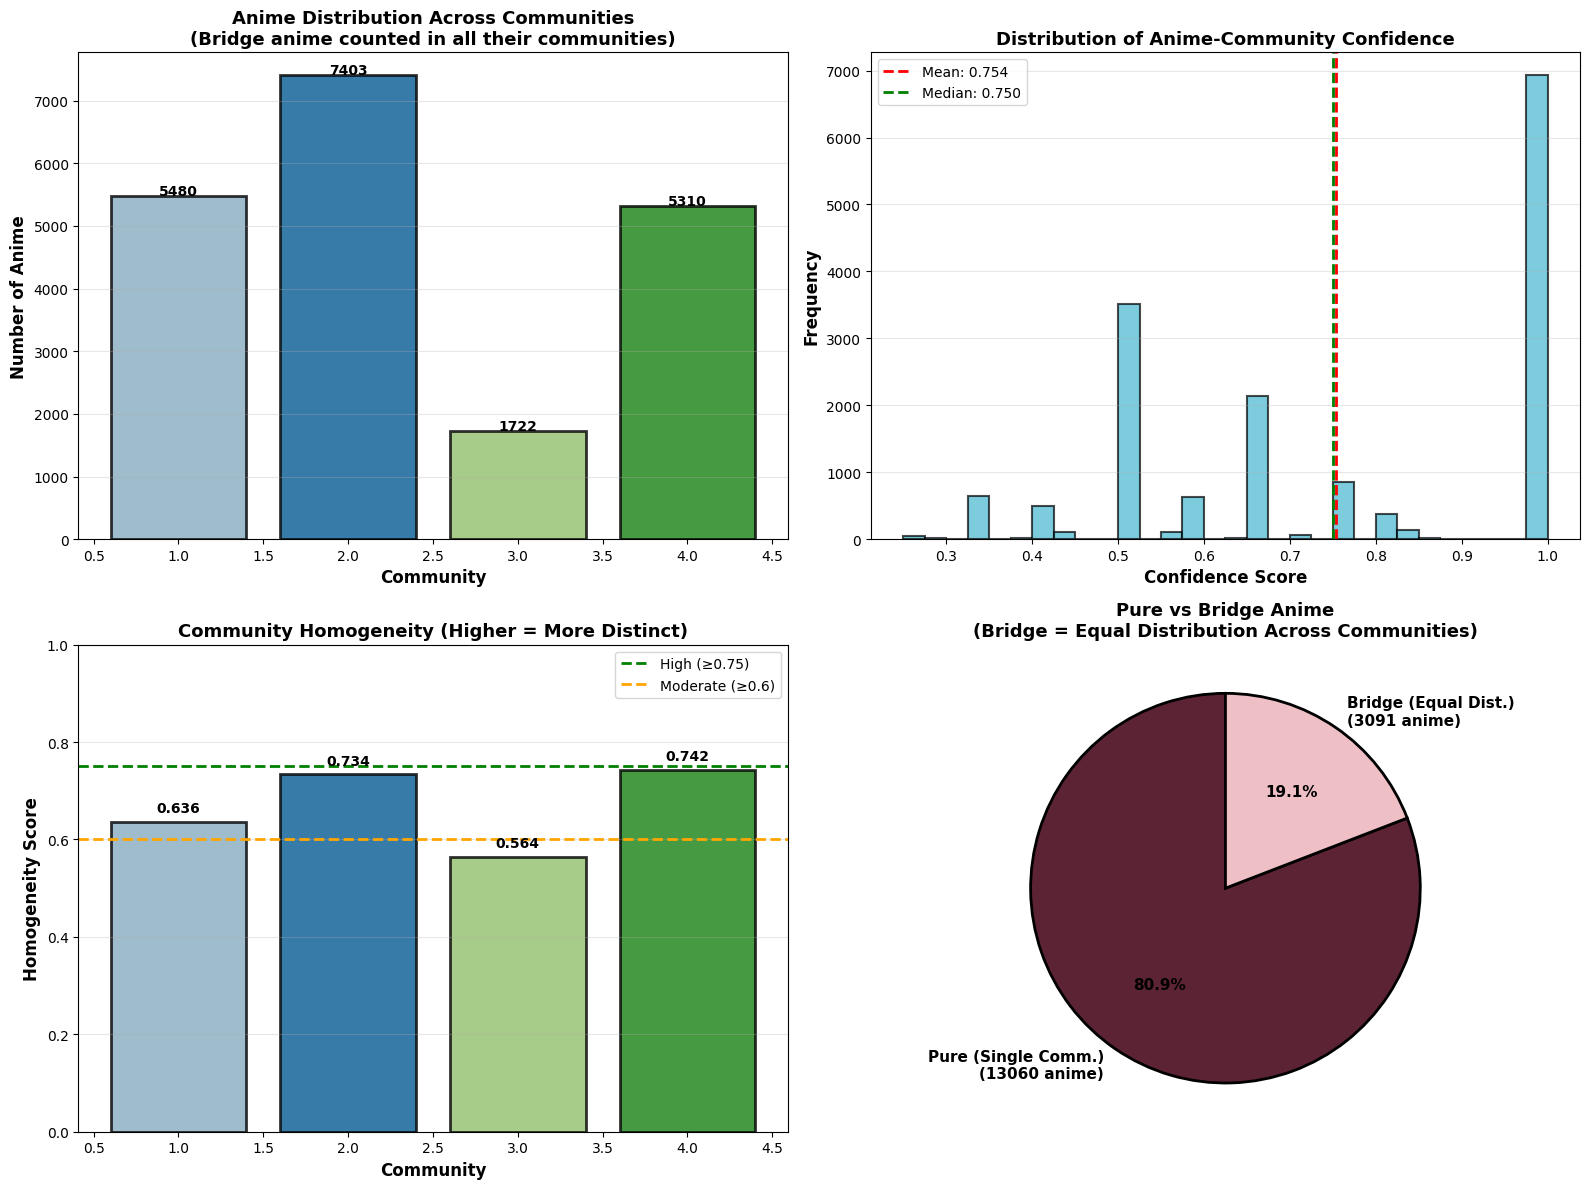


✓ NETWORK 2 ANALYSIS COMPLETE!

Next: Network 3 - User-Community Analysis


In [ ]:
# ============================================================================
# NETWORK 2 - ANIME-COMMUNITY DISTRIBUTION ANALYSIS (REVISED)
# ============================================================================

"""
PHASE 3 NETWORK 2 OVERVIEW (REVISED):
-------------------------------------
Goal: Analyze how anime distribute across genre communities to answer:
"Do communities get distinct anime, or do they heavily overlap?"

KEY DIFFERENCE FROM ORIGINAL:
- Bridge anime = equal distribution across multiple communities (true bridges)
- Non-bridge anime = assigned to single community with most genres

This script:
1. Loads the anime-community assignments from Phase 2 (revised)
2. Analyzes anime distribution across communities
3. Identifies and analyzes TRUE bridge anime (equal distribution)
4. Calculates community homogeneity
5. Visualizes anime clustering by community
"""

def load_and_validate_assignments(assignments_df):
    """
    [STEP 1] Load and validate the anime-community assignments from Phase 2 (revised)

    This loads the DataFrame we created in Phase 2 and validates it's intact.
    Key difference: now handles multiple assigned communities and true bridges.

    Args:
    - assignments_df: DataFrame from Phase 2 (revised) with anime assignments

    Returns:
    - assignments_df: Validated DataFrame with all necessary columns
    """
    print("\n" + "="*70)
    print("PHASE 3: NETWORK 2 - ANIME-COMMUNITY DISTRIBUTION ANALYSIS")
    print("="*70)

    print("\n[STEP 1] Loading Anime-Community Assignments from Phase 2 (Revised)")
    print("-" * 70)

    print(f"\n✓ Loaded assignments DataFrame")
    print(f"  Total anime: {len(assignments_df)}")
    print(f"  Columns: {list(assignments_df.columns)}")

    # Verify required columns exist
    required_cols = ['anime_id', 'anime_name', 'assigned_communities',
                     'confidence', 'is_bridge', 'communities_spanned']

    missing_cols = [col for col in required_cols if col not in assignments_df.columns]
    if missing_cols:
        print(f"\n⚠️  Warning: Missing columns: {missing_cols}")
        print(f"   Some analyses may be limited")

    # Display sample data
    print(f"\nSample assignments:")
    print(assignments_df[['anime_name', 'assigned_communities', 'confidence', 'is_bridge']].head(10))

    return assignments_df


def analyze_anime_distribution(assignments_df):
    """
    [STEP 2] Analyze how anime distribute across communities

    This measures:
    - How many anime in each community (counting bridges in all their communities)
    - Are communities well-populated or sparse?
    - Do anime evenly distribute or cluster in some communities?

    SEMANTIC MEANING:
    If anime distribute evenly across communities, it suggests genres
    don't create distinct anime groups. If they cluster, communities
    have distinct anime profiles.

    Args:
    - assignments_df: DataFrame with anime assignments

    Returns:
    - distribution_stats: Dictionary with distribution statistics
    """
    print("\n[STEP 2] Analyzing Anime Distribution Across Communities")
    print("-" * 70)

    # Count anime per community
    # Important: Bridge anime count in multiple communities
    community_anime_counts = defaultdict(set)

    for idx, row in assignments_df.iterrows():
        for community in row['assigned_communities']:
            community_anime_counts[community].add(row['anime_id'])

    # Convert to counts
    community_counts = {comm: len(anime_set) for comm, anime_set in community_anime_counts.items()}
    community_counts = pd.Series(community_counts).sort_index()

    print(f"\nAnime Count per Community:")
    print(f"(Note: Bridge anime are counted in all their communities)")
    for community_id, count in community_counts.items():
        percentage = (count / len(assignments_df)) * 100
        print(f"  Community {community_id}: {count:5d} anime ({percentage:5.1f}%)")

    # Calculate distribution statistics
    mean_anime = community_counts.mean()
    std_anime = community_counts.std()
    min_anime = community_counts.min()
    max_anime = community_counts.max()

    print(f"\nDistribution Statistics:")
    print(f"  Mean anime per community: {mean_anime:.1f}")
    print(f"  Std deviation: {std_anime:.1f}")
    print(f"  Min: {min_anime}")
    print(f"  Max: {max_anime}")

    # Coefficient of variation (how uneven is the distribution?)
    if mean_anime > 0:
        cv = (std_anime / mean_anime) * 100
        print(f"  Coefficient of variation: {cv:.1f}%")

        if cv < 20:
            print(f"  → Very even distribution (communities are similar size)")
        elif cv < 50:
            print(f"  → Moderate variation (some communities larger than others)")
        else:
            print(f"  → High variation (communities are quite different sizes)")

    stats = {
        'community_counts': community_counts,
        'mean': mean_anime,
        'std': std_anime,
        'min': min_anime,
        'max': max_anime,
        'cv': cv
    }

    return stats


def analyze_confidence_scores(assignments_df):
    """
    [STEP 3] Analyze anime-community confidence scores

    Confidence = (# of anime's genres in assigned community) / (total genres)

    For bridge anime: confidence is the % of genres in each of their communities
    (should be equal for true bridges)

    This measures:
    - How well do anime match their assigned communities?
    - Are assignments clear-cut or ambiguous?
    - Are there many "border" anime (low confidence)?

    SEMANTIC MEANING:
    High confidence means anime clearly belong to a community (most of their
    genres are in that community). Low confidence means anime are borderline.

    Args:
    - assignments_df: DataFrame with anime assignments

    Returns:
    - confidence_stats: Dictionary with confidence statistics
    """
    print("\n[STEP 3] Analyzing Anime-Community Confidence Scores")
    print("-" * 70)

    print(f"\nConfidence Score Statistics:")
    print(f"  (Higher confidence = anime clearly match their community/communities)")
    print(f"  {'-'*70}")

    print(f"\n  Mean: {assignments_df['confidence'].mean():.4f}")
    print(f"  Median: {assignments_df['confidence'].median():.4f}")
    print(f"  Std Dev: {assignments_df['confidence'].std():.4f}")
    print(f"  Min: {assignments_df['confidence'].min():.4f}")
    print(f"  Max: {assignments_df['confidence'].max():.4f}")

    # Distribution of confidence scores
    print(f"\nConfidence Score Distribution:")
    confidence_bins = pd.cut(assignments_df['confidence'],
                             bins=[0, 0.25, 0.5, 0.75, 1.0],
                             labels=['0-0.25', '0.25-0.5', '0.5-0.75', '0.75-1.0'])
    bin_counts = confidence_bins.value_counts().sort_index()

    for bin_label, count in bin_counts.items():
        percentage = (count / len(assignments_df)) * 100
        bar = '█' * int(percentage / 2)
        print(f"  {bin_label}: {count:5d} anime ({percentage:5.1f}%) {bar}")

    # Interpretation
    high_conf = len(assignments_df[assignments_df['confidence'] >= 0.75])
    high_conf_pct = (high_conf / len(assignments_df)) * 100

    low_conf = len(assignments_df[assignments_df['confidence'] < 0.5])
    low_conf_pct = (low_conf / len(assignments_df)) * 100

    print(f"\nInterpretation:")
    print(f"  High confidence (≥0.75): {high_conf:5d} anime ({high_conf_pct:5.1f}%)")
    print(f"  Low confidence (<0.5):   {low_conf:5d} anime ({low_conf_pct:5.1f}%)")

    if high_conf_pct > 70:
        print(f"  → Most anime clearly match their communities ✅")
    elif high_conf_pct > 50:
        print(f"  → Many anime match their communities")
    else:
        print(f"  → Communities are ambiguous, many borderline anime ⚠️")

    stats = {
        'mean_confidence': assignments_df['confidence'].mean(),
        'median_confidence': assignments_df['confidence'].median(),
        'high_conf_count': high_conf,
        'high_conf_pct': high_conf_pct,
        'low_conf_count': low_conf,
        'low_conf_pct': low_conf_pct
    }

    return stats


def analyze_bridge_anime_revised(assignments_df):
    """
    [STEP 4] Analyze TRUE bridge anime (equal distribution across communities)

    In the revised Phase 2:
    - Bridge anime have EQUAL genre distribution across multiple communities
    - They serve as gateways between communities
    - They represent the strongest connections between communities

    This measures:
    - How many true bridge anime exist?
    - Which communities do they connect?
    - What's their confidence level?

    SEMANTIC MEANING:
    True bridge anime show natural genre connections between communities.
    They indicate which communities are most similar or complementary.

    Args:
    - assignments_df: DataFrame with anime assignments

    Returns:
    - bridge_stats: Dictionary with bridge anime statistics
    """
    print("\n[STEP 4] Analyzing TRUE Bridge Anime (Equal Distribution)")
    print("-" * 70)

    bridge_anime = assignments_df[assignments_df['is_bridge']]
    pure_anime = assignments_df[~assignments_df['is_bridge']]

    bridge_pct = (len(bridge_anime) / len(assignments_df)) * 100
    pure_pct = (len(pure_anime) / len(assignments_df)) * 100

    print(f"\nBridge vs Pure Anime:")
    print(f"  Pure anime (single community): {len(pure_anime):5d} ({pure_pct:5.1f}%)")
    print(f"  Bridge anime (equal distribution): {len(bridge_anime):5d} ({bridge_pct:5.1f}%)")

    if bridge_pct > 50:
        print(f"  → Most anime are true bridges (communities heavily connected) ⚠️")
    elif bridge_pct > 30:
        print(f"  → Significant bridging between communities")
    else:
        print(f"  → Few anime truly bridge communities (good separation) ✅")

    # Distribution of how many communities bridge anime span
    print(f"\nBridge Anime Distribution (by communities spanned):")
    if len(bridge_anime) > 0:
        span_dist = bridge_anime['communities_spanned'].value_counts().sort_index()
        for num_communities, count in span_dist.items():
            percentage = (count / len(bridge_anime)) * 100
            print(f"  Spanning {num_communities} communities: {count:5d} anime ({percentage:5.1f}%)")

        # Average communities spanned
        avg_span = bridge_anime['communities_spanned'].mean()
        print(f"\n  Average communities spanned: {avg_span:.2f}")

    # Top bridge anime (those connecting the most communities)
    if len(bridge_anime) > 0:
        print(f"\nTop Bridge Anime (spanning most communities):")
        top_bridges = bridge_anime.nlargest(5, 'communities_spanned')[
            ['anime_name', 'assigned_communities', 'communities_spanned', 'confidence']
        ]
        for idx, row in top_bridges.iterrows():
            print(f"  • {row['anime_name']}")
            print(f"    Communities: {row['assigned_communities']}")
            print(f"    Spans {row['communities_spanned']} communities (confidence: {row['confidence']:.2f})")

    stats = {
        'total_bridge': len(bridge_anime),
        'bridge_pct': bridge_pct,
        'total_pure': len(pure_anime),
        'pure_pct': pure_pct
    }

    if len(bridge_anime) > 0:
        stats['avg_span'] = bridge_anime['communities_spanned'].mean()

    return stats


def analyze_community_homogeneity_revised(assignments_df):
    """
    [STEP 5] Analyze community homogeneity

    Homogeneity measures how "pure" a community is.
    - High homogeneity: community has anime with mostly that community's genres
    - Low homogeneity: community has diverse anime from multiple genre sources

    For BRIDGE ANIME: they contribute to lowering homogeneity because their
    genres are equally distributed across communities (by definition).

    SEMANTIC MEANING:
    High homogeneity means a community has a distinct anime profile - anime
    in that community tend to have genres primarily from that community.
    Low homogeneity means community members are diverse genre-wise, possibly
    due to bridging anime.

    Args:
    - assignments_df: DataFrame with anime assignments

    Returns:
    - homogeneity_stats: Dictionary with homogeneity per community
    """
    print("\n[STEP 5] Analyzing Community Homogeneity")
    print("-" * 70)

    print(f"\nCommunity Homogeneity (based on confidence scores):")
    print(f"(Higher = more distinct anime profile)")
    print(f"(Note: bridge anime lower homogeneity due to equal distribution)")
    print(f"{'-'*70}")

    homogeneity_stats = {}

    # Get unique communities
    all_communities = set()
    for communities_list in assignments_df['assigned_communities']:
        all_communities.update(communities_list)

    for community_id in sorted(all_communities):
        # Get all anime assigned to this community
        anime_in_community = assignments_df[
            assignments_df['assigned_communities'].apply(lambda x: community_id in x)
        ]

        if len(anime_in_community) > 0:
            # Homogeneity = average confidence of anime in this community
            homogeneity = anime_in_community['confidence'].mean()

            # Also calculate bridge vs pure anime
            bridge_in_community = len(anime_in_community[anime_in_community['is_bridge']])
            pure_in_community = len(anime_in_community[~anime_in_community['is_bridge']])

            # How many high-confidence anime
            high_conf_count = len(anime_in_community[anime_in_community['confidence'] >= 0.75])
            high_conf_pct = (high_conf_count / len(anime_in_community)) * 100

            homogeneity_stats[community_id] = {
                'homogeneity': homogeneity,
                'anime_count': len(anime_in_community),
                'bridge_anime': bridge_in_community,
                'pure_anime': pure_in_community,
                'high_conf_count': high_conf_count,
                'high_conf_pct': high_conf_pct,
                'std_confidence': anime_in_community['confidence'].std()
            }

            # Interpret homogeneity
            if homogeneity >= 0.8:
                interpretation = "Very high - distinct anime profile ✅"
            elif homogeneity >= 0.6:
                interpretation = "Moderate - some variation"
            else:
                interpretation = "Low - diverse anime ⚠️"

            print(f"\nCommunity {community_id}:")
            print(f"  Homogeneity: {homogeneity:.4f} → {interpretation}")
            print(f"  Anime in community: {len(anime_in_community)}")
            print(f"    - Pure anime: {pure_in_community}")
            print(f"    - Bridge anime: {bridge_in_community}")
            print(f"  High-confidence anime: {high_conf_count} ({high_conf_pct:.1f}%)")

    # Overall homogeneity
    overall_homogeneity = np.mean([s['homogeneity'] for s in homogeneity_stats.values()])
    print(f"\n{'='*70}")
    print(f"Overall Community Homogeneity: {overall_homogeneity:.4f}")
    print(f"{'='*70}")

    if overall_homogeneity >= 0.75:
        print(f"Interpretation: Communities have distinct anime profiles ✅")
    elif overall_homogeneity >= 0.60:
        print(f"Interpretation: Communities have some distinct profiles")
    else:
        print(f"Interpretation: Communities are not well-separated by anime ⚠️")

    return homogeneity_stats


def analyze_bridge_connections(assignments_df):
    """
    [STEP 6] Analyze which communities are connected by bridge anime

    For each pair of communities, count how many bridge anime connect them.
    This shows the strength of connections between communities.

    SEMANTIC MEANING:
    Many bridge anime between two communities means those communities have
    genres that naturally occur together. Strong connections indicate
    communities are not truly isolated.

    Args:
    - assignments_df: DataFrame with anime assignments

    Returns:
    - bridge_connections: DataFrame showing pairwise connections
    """
    print("\n[STEP 6] Analyzing Bridge Connections Between Communities")
    print("-" * 70)

    # Get all bridge anime
    bridge_anime = assignments_df[assignments_df['is_bridge']]

    # Get all communities
    all_communities = set()
    for communities_list in assignments_df['assigned_communities']:
        all_communities.update(communities_list)

    # Initialize connection matrix
    connection_matrix = pd.DataFrame(
        0,
        index=sorted(all_communities),
        columns=sorted(all_communities)
    )

    print(f"\nBridge Anime Connections Between Communities:")
    print(f"{'-'*70}")

    # For each bridge anime, add connections between its communities
    for idx, row in bridge_anime.iterrows():
        communities_in_anime = row['assigned_communities']

        # Add connection for each pair
        for i in range(len(communities_in_anime)):
            for j in range(i + 1, len(communities_in_anime)):
                c1 = communities_in_anime[i]
                c2 = communities_in_anime[j]
                connection_matrix.loc[c1, c2] += 1
                connection_matrix.loc[c2, c1] += 1

    # Display connection matrix
    print(f"\nConnection Matrix (number of bridge anime connecting communities):")
    print(connection_matrix.astype(int))

    # Find strongest connections
    print(f"\nStrongest Community Connections (via bridge anime):")
    connections = []
    for i in sorted(all_communities):
        for j in sorted(all_communities):
            if i < j and connection_matrix.loc[i, j] > 0:
                connections.append((i, j, connection_matrix.loc[i, j]))

    # Sort by strength
    connections.sort(key=lambda x: x[2], reverse=True)

    if connections:
        for c1, c2, strength in connections[:5]:
            print(f"  Community {c1} ↔ Community {c2}: {strength} bridge anime")
    else:
        print(f"  No bridge connections found (all anime assigned to single communities)")

    return connection_matrix


def generate_network2_summary(assignments_df, dist_stats, conf_stats,
                               bridge_stats, homogeneity_stats):
    """
    [STEP 7] Generate comprehensive summary of Network 2 findings

    Synthesizes all measures to answer:
    "Do communities get distinct anime, or do they heavily overlap?"

    Args:
    - All statistics from previous steps
    """
    print("\n[STEP 7] Network 2 Summary")
    print("="*70)

    print("\nRESEARCH QUESTION: Do communities get distinct anime?")
    print("="*70)

    # Aggregate evidence
    evidence_score = 0

    # Evidence 1: Distribution
    print(f"\n[EVIDENCE 1] Anime Distribution Across Communities")
    print(f"{'-'*70}")

    if dist_stats['cv'] < 30:
        print(f"  Even distribution (CV: {dist_stats['cv']:.1f}%) → Similar-sized communities")
        evidence_score += 1
    else:
        print(f"  Uneven distribution (CV: {dist_stats['cv']:.1f}%) → Some communities larger")
        evidence_score += 2

    # Evidence 2: Confidence
    print(f"\n[EVIDENCE 2] Anime-Community Confidence")
    print(f"{'-'*70}")

    if conf_stats['high_conf_pct'] > 75:
        print(f"  High confidence ({conf_stats['high_conf_pct']:.1f}%) → Anime clearly match communities ✅")
        evidence_score += 3
    elif conf_stats['high_conf_pct'] > 50:
        print(f"  Moderate confidence → Some anime match well")
        evidence_score += 2
    else:
        print(f"  Low confidence → Anime poorly match communities")
        evidence_score += 1

    # Evidence 3: Bridge anime
    print(f"\n[EVIDENCE 3] TRUE Bridge Anime Prevalence (Equal Distribution)")
    print(f"{'-'*70}")

    if bridge_stats['bridge_pct'] < 30:
        print(f"  Few bridge anime ({bridge_stats['bridge_pct']:.1f}%) → Communities well-separated ✅")
        evidence_score += 3
    elif bridge_stats['bridge_pct'] < 50:
        print(f"  Moderate bridging ({bridge_stats['bridge_pct']:.1f}%) → Some overlap")
        evidence_score += 2
    else:
        print(f"  Heavy bridging ({bridge_stats['bridge_pct']:.1f}%) → Communities heavily overlap")
        evidence_score += 1

    # Evidence 4: Homogeneity
    print(f"\n[EVIDENCE 4] Community Homogeneity")
    print(f"{'-'*70}")

    overall_homogeneity = np.mean([s['homogeneity'] for s in homogeneity_stats.values()])

    if overall_homogeneity > 0.75:
        print(f"  High homogeneity ({overall_homogeneity:.4f}) → Distinct communities ✅")
        evidence_score += 3
    elif overall_homogeneity > 0.60:
        print(f"  Moderate homogeneity → Somewhat distinct")
        evidence_score += 2
    else:
        print(f"  Low homogeneity → Not distinct")
        evidence_score += 1

    # Final verdict
    print(f"\n{'='*70}")
    print(f"Total Evidence Score: {evidence_score}/12")
    print(f"{'='*70}")

    if evidence_score >= 10:
        answer = "YES - STRONG EVIDENCE ✅✅✅"
        conclusion = "Communities get distinct anime profiles.\n" \
                    "Anime clearly cluster by genre community assignment."
    elif evidence_score >= 7:
        answer = "MODERATELY - Some distinct profiles ✓"
        conclusion = "Communities show some anime clustering, but with overlap.\n" \
                    "Some anime bridge multiple communities (equal distribution)."
    else:
        answer = "NO - Minimal distinction ⚠️"
        conclusion = "Communities do not get distinct anime.\n" \
                    "Many anime bridge between communities with equal distribution."

    print(f"\nANSWER: {answer}")
    print(f"CONCLUSION: {conclusion}")
    print(f"{'='*70}\n")


def visualize_anime_distribution(assignments_df, homogeneity_stats):
    """
    [STEP 8] Visualize anime distribution and community statistics

    Creates visualizations showing:
    - Anime count per community
    - Confidence score distribution
    - Community homogeneity
    - Bridge vs pure anime
    """
    print("\n[STEP 8] Creating Visualizations...")
    print("-" * 70)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # ─────────────────────────────────────────────────────────────────
    # Plot 1: Anime count per community
    # ─────────────────────────────────────────────────────────────────

    ax = axes[0, 0]

    # Count anime per community (including bridges in all their communities)
    community_anime_counts = defaultdict(set)
    for idx, row in assignments_df.iterrows():
        for community in row['assigned_communities']:
            community_anime_counts[community].add(row['anime_id'])

    community_counts = pd.Series({comm: len(anime_set)
                                 for comm, anime_set in community_anime_counts.items()}).sort_index()

    colors_comm = ['#86ACC0', '#055A93', '#91BE6B', '#188111']
    ax.bar(community_counts.index, community_counts.values,
           color=[colors_comm[i-1] for i in community_counts.index],
           alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_xlabel('Community', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Anime', fontsize=12, fontweight='bold')
    ax.set_title('Anime Distribution Across Communities\n(Bridge anime counted in all their communities)',
                fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, v in enumerate(community_counts.values):
        ax.text(community_counts.index[i], v + 20, str(int(v)), ha='center', fontweight='bold')

    # ─────────────────────────────────────────────────────────────────
    # Plot 2: Confidence score distribution
    # ─────────────────────────────────────────────────────────────────

    ax = axes[0, 1]
    ax.hist(assignments_df['confidence'], bins=30, color='#45B7D1', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axvline(assignments_df['confidence'].mean(), color='red', linestyle='--', linewidth=2,
              label=f'Mean: {assignments_df["confidence"].mean():.3f}')
    ax.axvline(assignments_df['confidence'].median(), color='green', linestyle='--', linewidth=2,
              label=f'Median: {assignments_df["confidence"].median():.3f}')
    ax.set_xlabel('Confidence Score', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of Anime-Community Confidence', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # ─────────────────────────────────────────────────────────────────
    # Plot 3: Community homogeneity
    # ─────────────────────────────────────────────────────────────────

    ax = axes[1, 0]
    communities = sorted(homogeneity_stats.keys())
    homogeneities = [homogeneity_stats[c]['homogeneity'] for c in communities]

    ax.bar(communities, homogeneities, color=[colors_comm[c-1] for c in communities],
          alpha=0.8, edgecolor='black', linewidth=2)
    ax.axhline(y=0.75, color='green', linestyle='--', linewidth=2, label='High (≥0.75)')
    ax.axhline(y=0.6, color='orange', linestyle='--', linewidth=2, label='Moderate (≥0.6)')
    ax.set_xlabel('Community', fontsize=12, fontweight='bold')
    ax.set_ylabel('Homogeneity Score', fontsize=12, fontweight='bold')
    ax.set_title('Community Homogeneity (Higher = More Distinct)', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(homogeneities):
        ax.text(communities[i], v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

    # ─────────────────────────────────────────────────────────────────
    # Plot 4: Bridge vs Pure Anime
    # ─────────────────────────────────────────────────────────────────

    ax = axes[1, 1]
    bridge_count = len(assignments_df[assignments_df['is_bridge']])
    pure_count = len(assignments_df[~assignments_df['is_bridge']])

    sizes = [pure_count, bridge_count]
    labels = [f'Pure (Single Comm.)\n({pure_count} anime)',
             f'Bridge (Equal Dist.)\n({bridge_count} anime)']
    colors_pie = ['#5B2333', '#EEC0C6']

    wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
                                        startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
                                        wedgeprops={'edgecolor': 'black', 'linewidth': 2})
    ax.set_title('Pure vs Bridge Anime\n(Bridge = Equal Distribution Across Communities)',
                fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.savefig('network2_anime_community_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ Visualization saved as 'network2_anime_community_distribution.png'")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_network2_analysis(assignments_df):
    """
    Run complete Network 2 analysis

    Args:
    - assignments_df: DataFrame from Phase 2 (revised) with anime-community assignments

    Returns:
    - network2_results: Dictionary with all analysis results
    """

    print("\n" + "="*70)
    print("STARTING NETWORK 2 ANALYSIS")
    print("="*70)

    # Step 1: Load and validate
    assignments_df = load_and_validate_assignments(assignments_df)

    # Step 2: Analyze distribution
    dist_stats = analyze_anime_distribution(assignments_df)

    # Step 3: Analyze confidence
    conf_stats = analyze_confidence_scores(assignments_df)

    # Step 4: Analyze bridge anime (REVISED)
    bridge_stats = analyze_bridge_anime_revised(assignments_df)

    # Step 5: Analyze homogeneity
    homogeneity_stats = analyze_community_homogeneity_revised(assignments_df)

    # Step 6: Analyze bridge connections
    connection_matrix = analyze_bridge_connections(assignments_df)

    # Step 7: Generate summary
    generate_network2_summary(assignments_df, dist_stats, conf_stats,
                            bridge_stats, homogeneity_stats)

    # Step 8: Visualize
    visualize_anime_distribution(assignments_df, homogeneity_stats)

    print("\n" + "="*70)
    print("✓ NETWORK 2 ANALYSIS COMPLETE!")
    print("="*70)
    print("\nNext: Network 3 - User-Community Analysis")

    # Return results for synthesis
    results = {
        'assignments': assignments_df,
        'distribution_stats': dist_stats,
        'confidence_stats': conf_stats,
        'bridge_stats': bridge_stats,
        'homogeneity_stats': homogeneity_stats,
        'connection_matrix': connection_matrix
    }

    return results


# ============================================================================
# RUN THE ANALYSIS
# ============================================================================

# Run Network 2 analysis using the assignments from Phase 2 (revised)
network2_results = run_network2_analysis(animeGenreComs_df)

## *Reflections on Network 2*

need to add

# Network 3 Analysis - Bipartite User - Genre Communities

Now we shall map the users to the genre community based on their anime list. For this first analysis we shall just work with users who have marked an anime as completed. This will garantee that the users' rating of an anime is based on their entire experience of it.

For future work we can include the other watch statuses to get a more holistic view of how users interact with anime in the different communities.

In [ ]:
#initial mapping method - following the procedure of network 2


STARTING NETWORK 3 ANALYSIS

PHASE 3: NETWORK 3 - USER-COMMUNITY MAPPING AND ANALYSIS

[STEP 1] Creating User-to-Community Mapping (Simplified)
----------------------------------------------------------------------

Merging user data with community assignments...
✓ Merged 1851275 completed ratings with community assignments
✓ Processing 9981 unique users

✓ User-to-community mapping complete!
  Total users assigned: 9981

Sample user assignments:
 user_id assigned_communities  num_communities  confidence  mean_rating
      17         [1, 2, 3, 4]                4    0.525568     6.863636
      32            [1, 2, 3]                3    0.500000     9.113636
      52         [1, 2, 3, 4]                4    0.629630     8.527778
      95         [1, 2, 3, 4]                4    0.529412     8.352941
     135         [1, 2, 3, 4]                4    0.483660     5.395425
     147         [1, 2, 3, 4]                4    0.659243     8.336303
     160         [1, 2, 3, 4]               

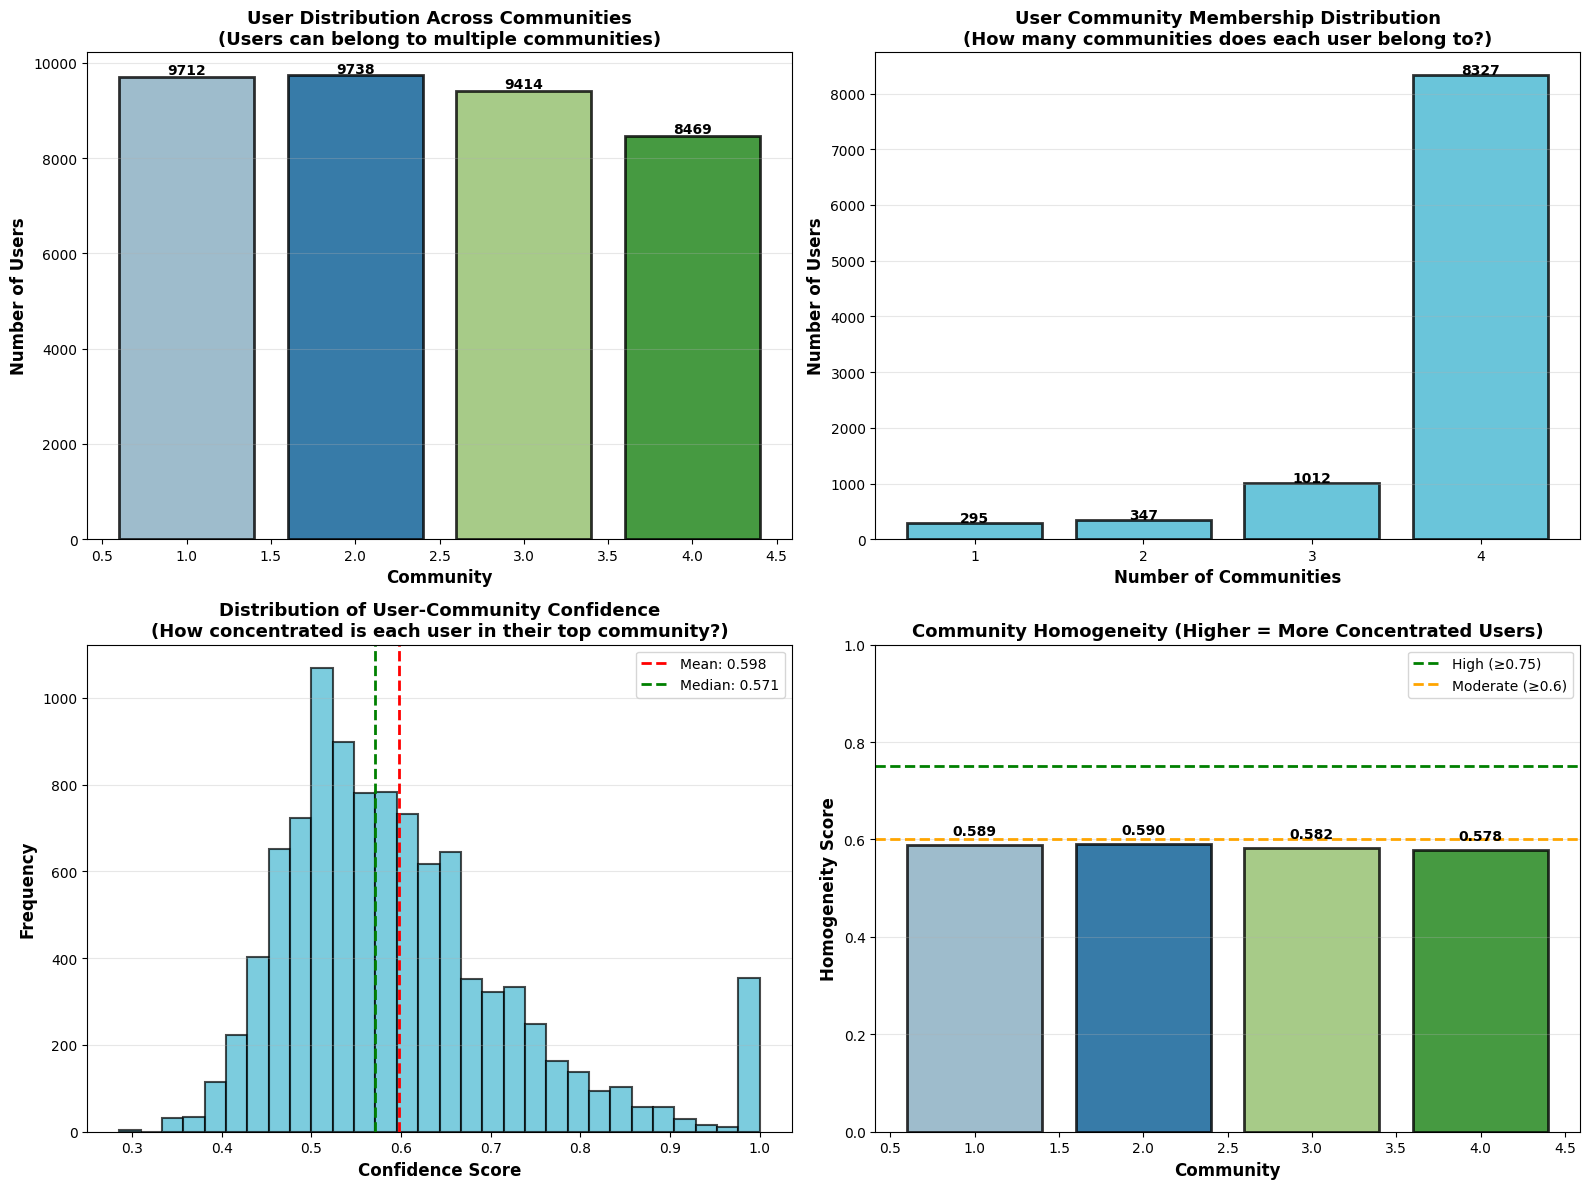


✓ NETWORK 3 ANALYSIS COMPLETE!

Next: Phase 3 Synthesis - Connecting all three networks


In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# PHASE 3: NETWORK 3 - USER-COMMUNITY MAPPING AND ANALYSIS
# ============================================================================

"""
PHASE 3 NETWORK 3 OVERVIEW (SIMPLIFIED):
----------------------------------------
Goal: Map each user to ALL genre communities based on their watched anime
and answer: "Do users distribute into the same communities as anime?"

This script:
1. Loads completed anime user data
2. For each user, identifies ALL communities their anime belongs to
3. Assigns users to all those communities (no bridge/equal distribution logic)
4. Analyzes user distribution and behavioral patterns by community
"""

def create_user_to_community_mapping(completed_anime_df, assignments_df):
    """
    [STEP 1] Create user-to-community assignments (simplified)

    For each user:
    1. Get all completed anime they watched
    2. Collect ALL communities those anime belong to
    3. Assign user to all those communities
    4. Calculate confidence = (anime in most common community) / total anime

    Args:
    - completed_anime_df: DataFrame with completed anime (user_id, anime_id, rating, etc.)
    - assignments_df: From Phase 2 with anime-community assignments

    Returns:
    - user_assignments_df: DataFrame with user-to-community assignments
    """
    print("\n" + "="*70)
    print("PHASE 3: NETWORK 3 - USER-COMMUNITY MAPPING AND ANALYSIS")
    print("="*70)

    print("\n[STEP 1] Creating User-to-Community Mapping (Simplified)")
    print("-" * 70)

    # Merge completed anime with community assignments
    print(f"\nMerging user data with community assignments...")

    merged_df = completed_anime_df.merge(
        assignments_df[['anime_id', 'assigned_communities']],
        on='anime_id',
        how='left'
    )

    # Remove records without community assignment
    merged_df = merged_df.dropna(subset=['assigned_communities'])

    print(f"✓ Merged {len(merged_df)} completed ratings with community assignments")

    # Get unique users
    user_ids = merged_df['user_id'].unique()
    print(f"✓ Processing {len(user_ids)} unique users")

    # Process each user
    user_assignments = []

    for user_id in user_ids:
        # Get all completed anime this user watched
        user_data = merged_df[merged_df['user_id'] == user_id]

        # Collect ALL communities this user's anime belongs to
        all_communities = set()
        community_counts = defaultdict(int)

        for idx, row in user_data.iterrows():
            # assigned_communities is a list
            if isinstance(row['assigned_communities'], list):
                for community in row['assigned_communities']:
                    if 1 <= community <= 4:
                        all_communities.add(community)
                        community_counts[community] += 1

        # If user has no community anime, skip
        if not all_communities:
            continue

        # Convert to sorted list
        assigned_communities = sorted(list(all_communities))

        # Calculate confidence as the proportion of anime in the user's most common community
        if community_counts:
            max_count = max(community_counts.values())
            confidence = max_count / len(user_data)
        else:
            confidence = 0

        # Store assignment
        user_assignments.append({
            'user_id': user_id,
            'assigned_communities': assigned_communities,
            'confidence': confidence,
            'num_anime_watched': len(user_data),
            'num_communities': len(assigned_communities),
            'community_distribution': dict(community_counts),
            'mean_rating': user_data['rating'].mean(),
            'median_rating': user_data['rating'].median(),
            'std_rating': user_data['rating'].std()
        })

    # Create DataFrame
    user_assignments_df = pd.DataFrame(user_assignments)

    print(f"\n✓ User-to-community mapping complete!")
    print(f"  Total users assigned: {len(user_assignments_df)}")

    # Display sample
    print(f"\nSample user assignments:")
    sample_df = user_assignments_df[[
        'user_id', 'assigned_communities', 'num_communities', 'confidence', 'mean_rating'
    ]].head(10)
    print(sample_df.to_string(index=False))

    return user_assignments_df


def analyze_user_distribution(user_assignments_df):
    """
    [STEP 2] Analyze how users distribute across communities

    Measures:
    - How many users in each community?
    - Are communities well-populated?
    - Do users evenly distribute or cluster?

    Args:
    - user_assignments_df: User-to-community assignments

    Returns:
    - distribution_stats: Dictionary with distribution statistics
    """
    print("\n[STEP 2] Analyzing User Distribution Across Communities")
    print("-" * 70)

    # Count users per community
    community_user_counts = defaultdict(int)

    for idx, row in user_assignments_df.iterrows():
        for community in row['assigned_communities']:
            community_user_counts[community] += 1

    # Convert to series for easier analysis
    community_counts = pd.Series(community_user_counts).sort_index()

    print(f"\nUsers per Community:")
    for community_id, count in community_counts.items():
        percentage = (count / len(user_assignments_df)) * 100
        print(f"  Community {community_id}: {count:5d} users ({percentage:5.1f}%)")

    # Calculate distribution statistics
    mean_users = community_counts.mean()
    std_users = community_counts.std()
    min_users = community_counts.min()
    max_users = community_counts.max()

    print(f"\nDistribution Statistics:")
    print(f"  Mean users per community: {mean_users:.1f}")
    print(f"  Std deviation: {std_users:.1f}")
    print(f"  Min: {min_users}")
    print(f"  Max: {max_users}")

    # Coefficient of variation
    if mean_users > 0:
        cv = (std_users / mean_users) * 100
        print(f"  Coefficient of variation: {cv:.1f}%")

        if cv < 20:
            print(f"  → Very even distribution (communities similar size)")
        elif cv < 50:
            print(f"  → Moderate variation (some communities larger than others)")
        else:
            print(f"  → High variation (communities quite different sizes)")

    stats = {
        'community_counts': community_counts,
        'mean': mean_users,
        'std': std_users,
        'min': min_users,
        'max': max_users,
        'cv': cv
    }

    return stats


def analyze_user_community_membership(user_assignments_df):
    """
    [STEP 2B] Analyze how many communities each user belongs to

    Measures:
    - How many communities does the average user engage with?
    - Do users specialize (1 community) or explore (multiple communities)?

    Args:
    - user_assignments_df: User-to-community assignments

    Returns:
    - membership_stats: Dictionary with membership statistics
    """
    print("\n[STEP 2B] Analyzing User Community Membership")
    print("-" * 70)

    print(f"\nCommunity Membership Distribution:")
    print(f"(How many communities does each user belong to?)")

    membership_dist = user_assignments_df['num_communities'].value_counts().sort_index()

    for num_communities, count in membership_dist.items():
        percentage = (count / len(user_assignments_df)) * 100
        bar = '█' * int(percentage / 2)
        print(f"  {num_communities} community: {count:5d} users ({percentage:5.1f}%) {bar}")

    # Statistics
    mean_communities = user_assignments_df['num_communities'].mean()
    median_communities = user_assignments_df['num_communities'].median()

    print(f"\nMembership Statistics:")
    print(f"  Mean communities per user: {mean_communities:.2f}")
    print(f"  Median communities per user: {median_communities:.1f}")

    # Calculate specialization
    specialist_count = len(user_assignments_df[user_assignments_df['num_communities'] == 1])
    specialist_pct = (specialist_count / len(user_assignments_df)) * 100

    explorer_count = len(user_assignments_df[user_assignments_df['num_communities'] >= 3])
    explorer_pct = (explorer_count / len(user_assignments_df)) * 100

    print(f"\nUser Types:")
    print(f"  Specialists (1 community): {specialist_count:5d} users ({specialist_pct:5.1f}%)")
    print(f"  Explorers (3+ communities): {explorer_count:5d} users ({explorer_pct:5.1f}%)")

    if specialist_pct > 50:
        print(f"  → Most users specialize in single community ✅")
    elif explorer_pct > 50:
        print(f"  → Most users explore multiple communities")
    else:
        print(f"  → Users are mixed (some specialists, some explorers)")

    stats = {
        'mean_communities': mean_communities,
        'median_communities': median_communities,
        'specialist_count': specialist_count,
        'specialist_pct': specialist_pct,
        'explorer_count': explorer_count,
        'explorer_pct': explorer_pct
    }

    return stats


def analyze_user_confidence_scores(user_assignments_df):
    """
    [STEP 3] Analyze user-community confidence scores

    Confidence = (# of user's anime in most common community) / (total anime watched)

    Measures:
    - How dominant is the user's primary community?
    - How spread are users across their assigned communities?

    Args:
    - user_assignments_df: User assignments

    Returns:
    - confidence_stats: Dictionary with confidence statistics
    """
    print("\n[STEP 3] Analyzing User-Community Confidence Scores")
    print("-" * 70)

    print(f"\nConfidence Score Statistics:")
    print(f"  (Higher confidence = user concentrated in one community)")
    print(f"  {'-'*70}")

    print(f"\n  Mean: {user_assignments_df['confidence'].mean():.4f}")
    print(f"  Median: {user_assignments_df['confidence'].median():.4f}")
    print(f"  Std Dev: {user_assignments_df['confidence'].std():.4f}")
    print(f"  Min: {user_assignments_df['confidence'].min():.4f}")
    print(f"  Max: {user_assignments_df['confidence'].max():.4f}")

    # Distribution of confidence scores
    print(f"\nConfidence Score Distribution:")
    confidence_bins = pd.cut(user_assignments_df['confidence'],
                            bins=[0, 0.25, 0.5, 0.75, 1.0],
                            labels=['0-0.25', '0.25-0.5', '0.5-0.75', '0.75-1.0'])
    bin_counts = confidence_bins.value_counts().sort_index()

    for bin_label, count in bin_counts.items():
        percentage = (count / len(user_assignments_df)) * 100
        bar = '█' * int(percentage / 2)
        print(f"  {bin_label}: {count:5d} users ({percentage:5.1f}%) {bar}")

    # Interpretation
    high_conf = len(user_assignments_df[user_assignments_df['confidence'] >= 0.75])
    high_conf_pct = (high_conf / len(user_assignments_df)) * 100

    low_conf = len(user_assignments_df[user_assignments_df['confidence'] < 0.5])
    low_conf_pct = (low_conf / len(user_assignments_df)) * 100

    print(f"\nInterpretation:")
    print(f"  High confidence (≥0.75): {high_conf:5d} users ({high_conf_pct:5.1f}%)")
    print(f"    → 75%+ of anime in one community (concentrated)")
    print(f"  Low confidence (<0.5):   {low_conf:5d} users ({low_conf_pct:5.1f}%)")
    print(f"    → <50% of anime in most common community (spread out)")

    if high_conf_pct > 50:
        print(f"\n  → Most users concentrated in single community ✅")
    else:
        print(f"\n  → Most users spread across communities")

    stats = {
        'mean_confidence': user_assignments_df['confidence'].mean(),
        'median_confidence': user_assignments_df['confidence'].median(),
        'high_conf_count': high_conf,
        'high_conf_pct': high_conf_pct,
        'low_conf_count': low_conf,
        'low_conf_pct': low_conf_pct
    }

    return stats


def analyze_user_homogeneity(user_assignments_df):
    """
    [STEP 4] Analyze community homogeneity based on users

    Homogeneity measures how "pure" a community is based on its users.
    - High homogeneity: community has users concentrated in that community
    - Low homogeneity: community has users spread across multiple communities

    Args:
    - user_assignments_df: User assignments

    Returns:
    - homogeneity_stats: Dictionary with homogeneity per community
    """
    print("\n[STEP 4] Analyzing Community Homogeneity")
    print("-" * 70)

    print(f"\nCommunity Homogeneity (based on user confidence scores):")
    print(f"(Higher = more concentrated users in community)")
    print(f"{'-'*70}")

    homogeneity_stats = {}

    # Get unique communities
    all_communities = set()
    for communities_list in user_assignments_df['assigned_communities']:
        all_communities.update(communities_list)

    for community_id in sorted(all_communities):
        # Get all users assigned to this community
        users_in_community = user_assignments_df[
            user_assignments_df['assigned_communities'].apply(lambda x: community_id in x)
        ]

        if len(users_in_community) > 0:
            # Homogeneity = average confidence of users in this community
            homogeneity = users_in_community['confidence'].mean()

            # How many users are single-community (focused on this one)
            single_comm_count = len(users_in_community[users_in_community['num_communities'] == 1])
            single_comm_pct = (single_comm_count / len(users_in_community)) * 100

            # How many high-confidence users
            high_conf_count = len(users_in_community[users_in_community['confidence'] >= 0.75])
            high_conf_pct = (high_conf_count / len(users_in_community)) * 100

            homogeneity_stats[community_id] = {
                'homogeneity': homogeneity,
                'user_count': len(users_in_community),
                'single_comm_count': single_comm_count,
                'single_comm_pct': single_comm_pct,
                'high_conf_count': high_conf_count,
                'high_conf_pct': high_conf_pct,
                'std_confidence': users_in_community['confidence'].std(),
                'mean_rating': users_in_community['mean_rating'].mean()
            }

            # Interpret homogeneity
            if homogeneity >= 0.8:
                interpretation = "Very high - concentrated user base ✅"
            elif homogeneity >= 0.6:
                interpretation = "Moderate - some concentration"
            else:
                interpretation = "Low - spread out users ⚠️"

            print(f"\nCommunity {community_id}:")
            print(f"  Homogeneity: {homogeneity:.4f} → {interpretation}")
            print(f"  Users in community: {len(users_in_community)}")
            print(f"    - Single-community users: {single_comm_count} ({single_comm_pct:.1f}%)")
            print(f"    - High-confidence users: {high_conf_count} ({high_conf_pct:.1f}%)")
            print(f"  Mean rating in community: {homogeneity_stats[community_id]['mean_rating']:.2f}")

    # Overall homogeneity
    overall_homogeneity = np.mean([s['homogeneity'] for s in homogeneity_stats.values()])
    print(f"\n{'='*70}")
    print(f"Overall Community Homogeneity: {overall_homogeneity:.4f}")
    print(f"{'='*70}")

    if overall_homogeneity >= 0.75:
        print(f"Interpretation: Communities have concentrated user bases ✅")
    elif overall_homogeneity >= 0.60:
        print(f"Interpretation: Communities have some concentration")
    else:
        print(f"Interpretation: Communities have diverse/spread users ⚠️")

    return homogeneity_stats


def analyze_community_overlap(user_assignments_df):
    """
    [STEP 5] Analyze which communities are frequently joined by users

    For each pair of communities, count how many users belong to both.
    This shows which communities naturally attract the same users.

    Args:
    - user_assignments_df: User assignments

    Returns:
    - overlap_matrix: DataFrame showing pairwise overlap
    """
    print("\n[STEP 5] Analyzing Community Overlap Through Users")
    print("-" * 70)

    # Get all communities
    all_communities = set()
    for communities_list in user_assignments_df['assigned_communities']:
        all_communities.update(communities_list)

    # Initialize overlap matrix
    overlap_matrix = pd.DataFrame(
        0,
        index=sorted(all_communities),
        columns=sorted(all_communities)
    )

    print(f"\nCommunity Overlap Analysis:")
    print(f"{'-'*70}")

    # For each user, add overlap between their communities
    for idx, row in user_assignments_df.iterrows():
        communities_in_user = row['assigned_communities']

        # Add overlap for each pair
        for i in range(len(communities_in_user)):
            for j in range(i + 1, len(communities_in_user)):
                c1 = communities_in_user[i]
                c2 = communities_in_user[j]
                overlap_matrix.loc[c1, c2] += 1
                overlap_matrix.loc[c2, c1] += 1

    # Display overlap matrix
    print(f"\nOverlap Matrix (number of users in both communities):")
    print(overlap_matrix.astype(int))

    # Find strongest connections
    print(f"\nStrongest Community Pairs (users in both):")
    connections = []
    for i in sorted(all_communities):
        for j in sorted(all_communities):
            if i < j and overlap_matrix.loc[i, j] > 0:
                connections.append((i, j, overlap_matrix.loc[i, j]))

    # Sort by strength
    connections.sort(key=lambda x: x[2], reverse=True)

    if connections:
        for c1, c2, strength in connections:
            print(f"  Community {c1} & {c2}: {strength} users in both")
    else:
        print(f"  No overlapping communities found")

    return overlap_matrix


def generate_network3_summary(user_assignments_df, dist_stats, membership_stats,
                              conf_stats, homogeneity_stats):
    """
    [STEP 6] Generate comprehensive summary of Network 3 findings

    Synthesizes all measures to answer:
    "Do users distribute into the same communities as anime?"

    Args:
    - All statistics from previous steps
    """
    print("\n[STEP 6] Network 3 Summary")
    print("="*70)

    print("\nRESEARCH QUESTION: Do users distribute into the same communities as anime?")
    print("="*70)

    # Aggregate evidence
    evidence_score = 0

    # Evidence 1: Distribution
    print(f"\n[EVIDENCE 1] User Distribution Across Communities")
    print(f"{'-'*70}")

    if dist_stats['cv'] < 30:
        print(f"  Even distribution (CV: {dist_stats['cv']:.1f}%) → Similar-sized communities")
        evidence_score += 1
    else:
        print(f"  Uneven distribution (CV: {dist_stats['cv']:.1f}%) → Some communities larger")
        evidence_score += 2

    # Evidence 2: Specialization
    print(f"\n[EVIDENCE 2] User Specialization")
    print(f"{'-'*70}")

    if membership_stats['specialist_pct'] > 70:
        print(f"  High specialization ({membership_stats['specialist_pct']:.1f}% single-community)")
        print(f"  → Users cluster in single communities ✅")
        evidence_score += 3
    elif membership_stats['specialist_pct'] > 50:
        print(f"  Moderate specialization ({membership_stats['specialist_pct']:.1f}%)")
        print(f"  → Some users specialize, some explore")
        evidence_score += 2
    else:
        print(f"  Low specialization ({membership_stats['specialist_pct']:.1f}%)")
        print(f"  → Most users explore multiple communities")
        evidence_score += 1

    # Evidence 3: Confidence
    print(f"\n[EVIDENCE 3] User-Community Concentration")
    print(f"{'-'*70}")

    if conf_stats['high_conf_pct'] > 70:
        print(f"  High concentration ({conf_stats['high_conf_pct']:.1f}% high confidence)")
        print(f"  → Users concentrate in one community ✅")
        evidence_score += 3
    elif conf_stats['high_conf_pct'] > 50:
        print(f"  Moderate concentration ({conf_stats['high_conf_pct']:.1f}%)")
        evidence_score += 2
    else:
        print(f"  Low concentration ({conf_stats['high_conf_pct']:.1f}%)")
        evidence_score += 1

    # Evidence 4: Homogeneity
    print(f"\n[EVIDENCE 4] Community Homogeneity")
    print(f"{'-'*70}")

    overall_homogeneity = np.mean([s['homogeneity'] for s in homogeneity_stats.values()])

    if overall_homogeneity > 0.75:
        print(f"  High homogeneity ({overall_homogeneity:.4f}) → Distinct communities ✅")
        evidence_score += 3
    elif overall_homogeneity > 0.60:
        print(f"  Moderate homogeneity → Somewhat distinct")
        evidence_score += 2
    else:
        print(f"  Low homogeneity → Not distinct")
        evidence_score += 1

    # Final verdict
    print(f"\n{'='*70}")
    print(f"Total Evidence Score: {evidence_score}/12")
    print(f"{'='*70}")

    if evidence_score >= 10:
        answer = "YES - STRONG EVIDENCE ✅✅✅"
        conclusion = "Users distribute into the same communities as anime.\n" \
                    "Genre communities structure user preferences effectively."
    elif evidence_score >= 7:
        answer = "MODERATELY - Some alignment ✓"
        conclusion = "Users show some tendency to cluster by community,\n" \
                    "but the structure is not perfectly clean."
    else:
        answer = "NO - Minimal alignment ⚠️"
        conclusion = "Users do not distribute into genre communities.\n" \
                    "User behavior is not well-structured by community boundaries."

    print(f"\nANSWER: {answer}")
    print(f"CONCLUSION: {conclusion}")
    print(f"{'='*70}\n")


def visualize_user_distribution(user_assignments_df, homogeneity_stats):
    """
    [STEP 7] Visualize user distribution and community statistics

    Creates visualizations showing:
    - User count per community
    - Community membership distribution
    - Confidence score distribution
    - Community homogeneity
    """
    print("\n[STEP 7] Creating Visualizations...")
    print("-" * 70)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # ─────────────────────────────────────────────────────────────────
    # Plot 1: User count per community
    # ─────────────────────────────────────────────────────────────────

    ax = axes[0, 0]

    # Count users per community
    community_user_counts = defaultdict(set)
    for idx, row in user_assignments_df.iterrows():
        for community in row['assigned_communities']:
            community_user_counts[community].add(row['user_id'])

    community_counts = pd.Series({comm: len(user_set)
                                 for comm, user_set in community_user_counts.items()}).sort_index()

    colors_comm = ['#86ACC0', '#055A93', '#91BE6B', '#188111']
    ax.bar(community_counts.index, community_counts.values,
           color=[colors_comm[i-1] for i in community_counts.index],
           alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_xlabel('Community', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
    ax.set_title('User Distribution Across Communities\n(Users can belong to multiple communities)',
                fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, v in enumerate(community_counts.values):
        ax.text(community_counts.index[i], v + 50, str(int(v)), ha='center', fontweight='bold')

    # ─────────────────────────────────────────────────────────────────
    # Plot 2: Community membership distribution
    # ─────────────────────────────────────────────────────────────────

    ax = axes[0, 1]

    membership_dist = user_assignments_df['num_communities'].value_counts().sort_index()

    ax.bar(membership_dist.index, membership_dist.values, color='#45B7D1', alpha=0.8,
           edgecolor='black', linewidth=2)
    ax.set_xlabel('Number of Communities', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
    ax.set_title('User Community Membership Distribution\n(How many communities does each user belong to?)',
                fontsize=13, fontweight='bold')
    ax.set_xticks(membership_dist.index)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(membership_dist.values):
        ax.text(membership_dist.index[i], v + 20, str(int(v)), ha='center', fontweight='bold')

    # ─────────────────────────────────────────────────────────────────
    # Plot 3: Confidence score distribution
    # ─────────────────────────────────────────────────────────────────

    ax = axes[1, 0]
    ax.hist(user_assignments_df['confidence'], bins=30, color='#45B7D1', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axvline(user_assignments_df['confidence'].mean(), color='red', linestyle='--', linewidth=2,
              label=f'Mean: {user_assignments_df["confidence"].mean():.3f}')
    ax.axvline(user_assignments_df['confidence'].median(), color='green', linestyle='--', linewidth=2,
              label=f'Median: {user_assignments_df["confidence"].median():.3f}')
    ax.set_xlabel('Confidence Score', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of User-Community Confidence\n(How concentrated is each user in their top community?)',
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # ─────────────────────────────────────────────────────────────────
    # Plot 4: Community homogeneity
    # ─────────────────────────────────────────────────────────────────

    ax = axes[1, 1]
    communities = sorted(homogeneity_stats.keys())
    homogeneities = [homogeneity_stats[c]['homogeneity'] for c in communities]

    ax.bar(communities, homogeneities, color=[colors_comm[c-1] for c in communities],
          alpha=0.8, edgecolor='black', linewidth=2)
    ax.axhline(y=0.75, color='green', linestyle='--', linewidth=2, label='High (≥0.75)')
    ax.axhline(y=0.6, color='orange', linestyle='--', linewidth=2, label='Moderate (≥0.6)')
    ax.set_xlabel('Community', fontsize=12, fontweight='bold')
    ax.set_ylabel('Homogeneity Score', fontsize=12, fontweight='bold')
    ax.set_title('Community Homogeneity (Higher = More Concentrated Users)', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(homogeneities):
        ax.text(communities[i], v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('network3_user_community_mapping.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ Visualization saved as 'network3_user_community_mapping.png'")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_network3_analysis(completed_anime_df, assignments_df):
    """
    Run complete Network 3 analysis

    Args:
    - completed_anime_df: CSV with completed anime (filtered for completed status)
    - assignments_df: From Phase 2 with anime-community assignments

    Returns:
    - network3_results: Dictionary with all analysis results
    """

    print("\n" + "="*70)
    print("STARTING NETWORK 3 ANALYSIS")
    print("="*70)

    # Step 1: Create user-to-community mapping
    user_assignments_df = create_user_to_community_mapping(completed_anime_df, assignments_df)

    # Step 2: Analyze distribution
    dist_stats = analyze_user_distribution(user_assignments_df)

    # Step 2B: Analyze community membership
    membership_stats = analyze_user_community_membership(user_assignments_df)

    # Step 3: Analyze confidence
    conf_stats = analyze_user_confidence_scores(user_assignments_df)

    # Step 4: Analyze homogeneity
    homogeneity_stats = analyze_user_homogeneity(user_assignments_df)

    # Step 5: Analyze overlap
    overlap_matrix = analyze_community_overlap(user_assignments_df)

    # Step 6: Generate summary
    generate_network3_summary(user_assignments_df, dist_stats, membership_stats,
                            conf_stats, homogeneity_stats)

    # Step 7: Visualize
    visualize_user_distribution(user_assignments_df, homogeneity_stats)

    print("\n" + "="*70)
    print("✓ NETWORK 3 ANALYSIS COMPLETE!")
    print("="*70)
    print("\nNext: Phase 3 Synthesis - Connecting all three networks")

    # Return results for synthesis
    results = {
        'assignments': user_assignments_df,
        'distribution_stats': dist_stats,
        'membership_stats': membership_stats,
        'confidence_stats': conf_stats,
        'homogeneity_stats': homogeneity_stats,
        'overlap_matrix': overlap_matrix
    }

    return results


# ============================================================================
# RUN THE ANALYSIS
# ============================================================================

# Run Network 3 analysis using the assignments from Phase 2
completed_anime_df = pd.read_csv('/content/user_animelist_sampled.csv')
network3_results = run_network3_analysis(completed_anime_df, animeGenreComs_df)

In [ ]:
# this first method did not produce very interesting results so we reowrked it and ran it again


STARTING NETWORK 3 ANALYSIS (OPTION 2: PROPORTIONAL ENGAGEMENT)

PHASE 3: NETWORK 3 - USER SEGMENTATION BY PROPORTIONAL ENGAGEMENT

[STEP 1] Creating User Proportion Profiles
----------------------------------------------------------------------

Merging user data with community assignments...
✓ Merged 1851275 completed ratings with community assignments
✓ Processing 9981 unique users

✓ User proportion profiles created!
  Total users with profiles: 9981

Sample user proportion profiles:
user_id    C1 %     C2 %     C3 %     C4 %     Anime   
------------------------------------------------------------
17         34.4%    45.8%    12.7%    7.1%    704     
32         32.7%    42.3%    25.0%    0.0%    44      
52         30.5%    53.1%    7.8%    8.6%    216     
95         27.8%    50.0%    11.1%    11.1%    17      
135        32.9%    41.2%    16.7%    9.2%    306     
147        25.5%    57.1%    6.9%    10.4%    449     
160        43.8%    30.2%    22.6%    3.5%    243     
164 

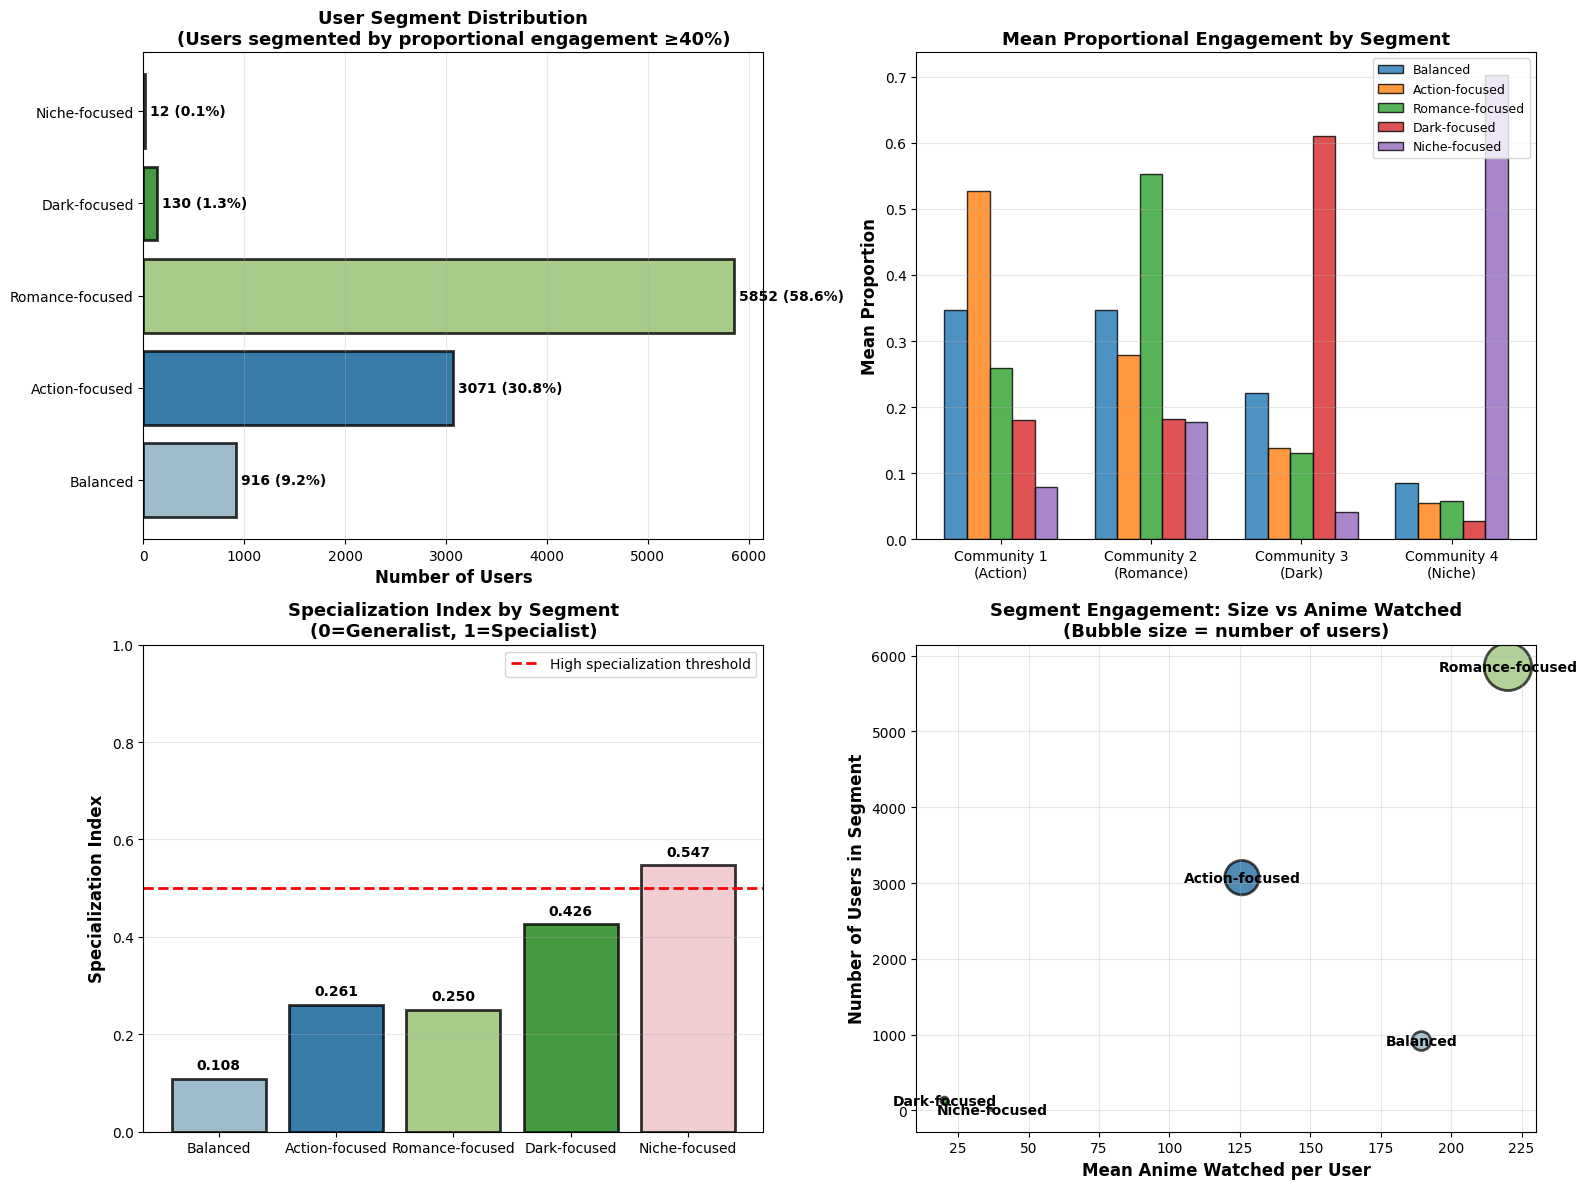


✓ NETWORK 3 ANALYSIS COMPLETE!

Next: Phase 3 Synthesis - Connecting all three networks


In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# PHASE 3: NETWORK 3 - USER SEGMENTATION BY PROPORTIONAL ENGAGEMENT
# ============================================================================

"""
PHASE 3 NETWORK 3 OVERVIEW (OPTION 2):
--------------------------------------
Goal: Segment users by their proportional engagement with communities
and answer: "Do users show distinct preferences across communities?"

This script:
1. Loads completed anime user data
2. For each user, calculates proportion of anime from each community
3. Creates engagement proportion vectors
4. Segments users into archetypes based on proportional preferences:
   - Specialists (40%+ in one community)
   - Balanced explorers (relatively even across multiple)
   - Niche enthusiasts (high engagement in Communities 3&4)
5. Analyzes characteristics and behavior of each segment
"""

def create_user_proportion_profiles(completed_anime_df, assignments_df):
    """
    [STEP 1] Create user proportion profiles

    For each user:
    1. Get all completed anime they watched
    2. Count anime from each community
    3. Calculate proportions (normalize to 0-1)
    4. Create engagement proportion vector

    Args:
    - completed_anime_df: DataFrame with completed anime (user_id, anime_id, rating, etc.)
    - assignments_df: From Phase 2 with anime-community assignments

    Returns:
    - user_profiles_df: DataFrame with user proportion profiles
    """
    print("\n" + "="*70)
    print("PHASE 3: NETWORK 3 - USER SEGMENTATION BY PROPORTIONAL ENGAGEMENT")
    print("="*70)

    print("\n[STEP 1] Creating User Proportion Profiles")
    print("-" * 70)

    # Merge completed anime with community assignments
    print(f"\nMerging user data with community assignments...")

    merged_df = completed_anime_df.merge(
        assignments_df[['anime_id', 'assigned_communities']],
        on='anime_id',
        how='left'
    )

    # Remove records without community assignment
    merged_df = merged_df.dropna(subset=['assigned_communities'])

    print(f"✓ Merged {len(merged_df)} completed ratings with community assignments")

    # Get unique users
    user_ids = merged_df['user_id'].unique()
    print(f"✓ Processing {len(user_ids)} unique users")

    # Process each user
    user_profiles = []

    for user_id in user_ids:
        # Get all completed anime this user watched
        user_data = merged_df[merged_df['user_id'] == user_id]

        # Count anime in each community
        community_counts = defaultdict(int)

        for idx, row in user_data.iterrows():
            # assigned_communities is a list - count in each
            if isinstance(row['assigned_communities'], list):
                for community in row['assigned_communities']:
                    if 1 <= community <= 4:
                        community_counts[community] += 1

        # If user has no community anime, skip
        if not community_counts:
            continue

        # Calculate proportions
        total_anime = sum(community_counts.values())
        proportions = {
            1: community_counts[1] / total_anime if 1 in community_counts else 0,
            2: community_counts[2] / total_anime if 2 in community_counts else 0,
            3: community_counts[3] / total_anime if 3 in community_counts else 0,
            4: community_counts[4] / total_anime if 4 in community_counts else 0
        }

        # Create proportion vector
        proportion_vector = [proportions[1], proportions[2], proportions[3], proportions[4]]

        # Store profile
        user_profiles.append({
            'user_id': user_id,
            'num_anime_watched': len(user_data),
            'community_counts': dict(community_counts),
            'community_proportions': proportions,
            'proportion_vector': proportion_vector,
            'mean_rating': user_data['rating'].mean(),
            'median_rating': user_data['rating'].median(),
            'std_rating': user_data['rating'].std()
        })

    # Create DataFrame
    user_profiles_df = pd.DataFrame(user_profiles)

    print(f"\n✓ User proportion profiles created!")
    print(f"  Total users with profiles: {len(user_profiles_df)}")

    # Display sample
    print(f"\nSample user proportion profiles:")
    print(f"{'user_id':<10} {'C1 %':<8} {'C2 %':<8} {'C3 %':<8} {'C4 %':<8} {'Anime':<8}")
    print("-" * 60)
    for idx, row in user_profiles_df.head(10).iterrows():
        props = row['community_proportions']
        print(f"{row['user_id']:<10} {props[1]:.1%}    {props[2]:.1%}    {props[3]:.1%}    {props[4]:.1%}    {row['num_anime_watched']:<8}")

    return user_profiles_df


def segment_users_by_proportion(user_profiles_df):
    """
    [STEP 2] Segment users into archetypes based on proportional engagement

    Thresholds:
    - Specialist: 40%+ in one community
    - Action-focused: 40%+ in Community 1
    - Romance-focused: 40%+ in Community 2
    - Dark-focused: 40%+ in Community 3
    - Niche-focused: 40%+ in Community 4
    - Balanced: no community ≥40%

    Args:
    - user_profiles_df: User proportion profiles

    Returns:
    - user_profiles_df: Updated with segment assignment
    - segment_stats: Dictionary with segment statistics
    """
    print("\n[STEP 2] Segmenting Users by Proportional Engagement")
    print("-" * 70)

    # Define segmentation thresholds
    SPECIALIST_THRESHOLD = 0.40

    segments = []

    for idx, row in user_profiles_df.iterrows():
        props = row['community_proportions']

        # Find which community(ies) have highest proportion
        max_prop = max(props[1], props[2], props[3], props[4])

        # Determine segment
        if max_prop >= SPECIALIST_THRESHOLD:
            # User is specialist in something
            if props[1] >= SPECIALIST_THRESHOLD:
                segment = "Action-focused"
                segment_id = 1
            elif props[2] >= SPECIALIST_THRESHOLD:
                segment = "Romance-focused"
                segment_id = 2
            elif props[3] >= SPECIALIST_THRESHOLD:
                segment = "Dark-focused"
                segment_id = 3
            else:  # props[4] >= SPECIALIST_THRESHOLD
                segment = "Niche-focused"
                segment_id = 4
        else:
            # User is balanced
            segment = "Balanced"
            segment_id = 0

        segments.append({
            'segment': segment,
            'segment_id': segment_id,
            'max_proportion': max_prop
        })

    # Add segments to dataframe
    segments_df = pd.DataFrame(segments)
    user_profiles_df = pd.concat([user_profiles_df, segments_df], axis=1)

    # Calculate segment statistics
    print(f"\nUser Segmentation Results:")
    print(f"{'-'*70}")

    segment_stats = {}

    for segment in ["Balanced", "Action-focused", "Romance-focused", "Dark-focused", "Niche-focused"]:
        segment_users = user_profiles_df[user_profiles_df['segment'] == segment]

        if len(segment_users) > 0:
            percentage = (len(segment_users) / len(user_profiles_df)) * 100
            mean_anime = segment_users['num_anime_watched'].mean()
            mean_rating = segment_users['mean_rating'].mean()

            segment_stats[segment] = {
                'count': len(segment_users),
                'percentage': percentage,
                'mean_anime': mean_anime,
                'mean_rating': mean_rating
            }

            print(f"\n{segment}:")
            print(f"  Users: {len(segment_users):5d} ({percentage:5.1f}%)")
            print(f"  Mean anime watched: {mean_anime:.1f}")
            print(f"  Mean rating: {mean_rating:.2f}")

            # Show engagement patterns
            mean_props = segment_users['community_proportions'].apply(
                lambda x: pd.Series(x)
            ).mean()
            print(f"  Engagement pattern:")
            print(f"    Community 1 (Action): {mean_props[1]:.1%}")
            print(f"    Community 2 (Romance): {mean_props[2]:.1%}")
            print(f"    Community 3 (Dark): {mean_props[3]:.1%}")
            print(f"    Community 4 (Niche): {mean_props[4]:.1%}")

    return user_profiles_df, segment_stats


def analyze_segment_characteristics(user_profiles_df, completed_anime_df, assignments_df):
    """
    [STEP 3] Analyze behavioral characteristics of each segment

    For each segment, analyze:
    - Rating patterns by community
    - Anime diversity
    - Community-specific preferences

    Args:
    - user_profiles_df: Users with segment assignments
    - completed_anime_df: Original anime data
    - assignments_df: Community assignments

    Returns:
    - characteristics_stats: Dictionary with detailed statistics
    """
    print("\n[STEP 3] Analyzing Segment Characteristics")
    print("-" * 70)

    # Merge data for analysis
    merged_df = completed_anime_df.merge(
        assignments_df[['anime_id', 'assigned_communities']],
        on='anime_id',
        how='left'
    ).dropna(subset=['assigned_communities'])

    merged_df = merged_df.merge(
        user_profiles_df[['user_id', 'segment']],
        on='user_id',
        how='left'
    ).dropna(subset=['segment'])

    characteristics_stats = {}

    for segment in ["Balanced", "Action-focused", "Romance-focused", "Dark-focused", "Niche-focused"]:
        segment_data = merged_df[merged_df['segment'] == segment]

        if len(segment_data) == 0:
            continue

        # Ratings by community
        rating_by_community = {}
        for comm in range(1, 5):
            comm_data = segment_data[
                segment_data['assigned_communities'].apply(
                    lambda x: isinstance(x, list) and comm in x
                )
            ]
            if len(comm_data) > 0:
                rating_by_community[comm] = {
                    'mean_rating': comm_data['rating'].mean(),
                    'std_rating': comm_data['rating'].std(),
                    'count': len(comm_data)
                }

        # Overall statistics
        characteristics_stats[segment] = {
            'total_ratings': len(segment_data),
            'rating_by_community': rating_by_community,
            'overall_mean_rating': segment_data['rating'].mean(),
            'overall_std_rating': segment_data['rating'].std()
        }

        print(f"\n{segment}:")
        print(f"  Total ratings: {len(segment_data)}")
        print(f"  Overall mean rating: {segment_data['rating'].mean():.2f}")
        print(f"  Ratings by community:")
        for comm in range(1, 5):
            if comm in rating_by_community:
                stats = rating_by_community[comm]
                print(f"    Community {comm}: {stats['mean_rating']:.2f} ± {stats['std_rating']:.2f} ({stats['count']} ratings)")

    return characteristics_stats


def analyze_segment_community_preference(user_profiles_df):
    """
    [STEP 4] Analyze how segments differ in community preferences

    For each segment, calculate:
    - Average proportion in each community
    - Variance of preferences
    - Specialization strength

    Args:
    - user_profiles_df: Users with segment assignments

    Returns:
    - preference_stats: Dictionary with preference statistics
    """
    print("\n[STEP 4] Analyzing Segment Community Preferences")
    print("-" * 70)

    preference_stats = {}

    for segment in ["Balanced", "Action-focused", "Romance-focused", "Dark-focused", "Niche-focused"]:
        segment_users = user_profiles_df[user_profiles_df['segment'] == segment]

        if len(segment_users) == 0:
            continue

        # Get proportion vectors
        proportion_vectors = np.array([v for v in segment_users['proportion_vector']])

        # Calculate statistics
        mean_vector = proportion_vectors.mean(axis=0)
        std_vector = proportion_vectors.std(axis=0)

        # Calculate specialization (using entropy)
        from scipy.stats import entropy

        entropies = []
        for vector in proportion_vectors:
            # Only calculate entropy for non-zero proportions
            non_zero = vector[vector > 0]
            if len(non_zero) > 0:
                ent = entropy(non_zero)
                entropies.append(ent)

        mean_entropy = np.mean(entropies) if entropies else 0
        max_entropy = np.log(4)  # Maximum entropy with 4 communities
        specialization = 1 - (mean_entropy / max_entropy)  # 0 = generalist, 1 = specialist

        preference_stats[segment] = {
            'mean_proportions': {1: mean_vector[0], 2: mean_vector[1],
                               3: mean_vector[2], 4: mean_vector[3]},
            'std_proportions': {1: std_vector[0], 2: std_vector[1],
                              3: std_vector[2], 4: std_vector[3]},
            'specialization_index': specialization,
            'mean_entropy': mean_entropy
        }

        print(f"\n{segment}:")
        print(f"  Mean proportions:")
        for comm in range(1, 5):
            print(f"    Community {comm}: {mean_vector[comm-1]:.1%} ± {std_vector[comm-1]:.1%}")
        print(f"  Specialization index: {specialization:.4f} (0=generalist, 1=specialist)")

    return preference_stats


def generate_network3_summary(user_profiles_df, segment_stats, characteristics_stats, preference_stats):
    """
    [STEP 5] Generate comprehensive summary of Network 3 findings

    Synthesizes all measures to answer:
    "Do users show distinct preferences across communities?"

    Args:
    - All statistics from previous steps
    """
    print("\n[STEP 5] Network 3 Summary")
    print("="*70)

    print("\nRESEARCH QUESTION: Do users show distinct preferences across communities?")
    print("="*70)

    # Aggregate evidence
    evidence_score = 0

    # Evidence 1: Segment size distribution
    print(f"\n[EVIDENCE 1] Segment Distribution")
    print(f"{'-'*70}")

    if segment_stats:
        balanced_pct = segment_stats.get("Balanced", {}).get('percentage', 0)
        specialist_pct = 100 - balanced_pct

        print(f"  Balanced users: {balanced_pct:.1f}%")
        print(f"  Specialist users: {specialist_pct:.1f}%")

        if specialist_pct > 50:
            print(f"  → Most users show clear specialization ✅")
            evidence_score += 3
        elif specialist_pct > 30:
            print(f"  → Significant specialist population")
            evidence_score += 2
        else:
            print(f"  → Mostly balanced users")
            evidence_score += 1

    # Evidence 2: Segment diversity
    print(f"\n[EVIDENCE 2] Segment Diversity")
    print(f"{'-'*70}")

    num_segments = len([s for s in segment_stats.keys() if segment_stats[s]['count'] > 0])
    print(f"  Active segments: {num_segments}/5")

    if num_segments >= 4:
        print(f"  → Multiple distinct user types identified ✅")
        evidence_score += 3
    elif num_segments >= 3:
        print(f"  → Several distinct user types identified")
        evidence_score += 2
    else:
        print(f"  → Limited user type diversity")
        evidence_score += 1

    # Evidence 3: Rating differences between segments
    print(f"\n[EVIDENCE 3] Behavioral Differences Between Segments")
    print(f"{'-'*70}")

    if characteristics_stats:
        ratings = [stats.get('overall_mean_rating', 0) for stats in characteristics_stats.values()]
        if ratings:
            rating_range = max(ratings) - min(ratings)
            print(f"  Rating range across segments: {rating_range:.2f} points")

            if rating_range > 0.3:
                print(f"  → Segments show different rating behaviors ✅")
                evidence_score += 2
            elif rating_range > 0.1:
                print(f"  → Some rating differences between segments")
                evidence_score += 1
            else:
                print(f"  → Minimal rating differences")
                evidence_score += 0

    # Evidence 4: Specialization index variation
    print(f"\n[EVIDENCE 4] Specialization Variation")
    print(f"{'-'*70}")

    if preference_stats:
        specializations = [stats['specialization_index'] for stats in preference_stats.values()]
        if specializations:
            spec_range = max(specializations) - min(specializations)
            print(f"  Specialization range: {spec_range:.4f}")

            if spec_range > 0.2:
                print(f"  → Clear variation in specialization across segments ✅")
                evidence_score += 3
            elif spec_range > 0.1:
                print(f"  → Some specialization variation")
                evidence_score += 2
            else:
                print(f"  → Limited specialization variation")
                evidence_score += 1

    # Final verdict
    print(f"\n{'='*70}")
    print(f"Total Evidence Score: {evidence_score}/11")
    print(f"{'='*70}")

    if evidence_score >= 9:
        answer = "YES - STRONG EVIDENCE ✅✅✅"
        conclusion = "Users show distinct preferences across communities.\n" \
                    "Clear user segments with different engagement patterns exist."
    elif evidence_score >= 6:
        answer = "MODERATELY - Some distinctions ✓"
        conclusion = "Some user segments show distinct preferences,\n" \
                    "though many users remain generalists."
    else:
        answer = "NO - Minimal distinctions ⚠️"
        conclusion = "Users do not show strong community preferences.\n" \
                    "Most users are balanced/generalist across communities."

    print(f"\nANSWER: {answer}")
    print(f"CONCLUSION: {conclusion}")
    print(f"{'='*70}\n")


def visualize_user_segments(user_profiles_df, segment_stats, preference_stats):
    """
    [STEP 6] Visualize user segments and their characteristics

    Creates visualizations showing:
    - Segment size distribution
    - Proportion vectors by segment (radar/bar charts)
    - Specialization index
    - Rating patterns by segment
    """
    print("\n[STEP 6] Creating Visualizations...")
    print("-" * 70)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # ─────────────────────────────────────────────────────────────────
    # Plot 1: Segment size distribution
    # ─────────────────────────────────────────────────────────────────

    ax = axes[0, 0]

    segments = list(segment_stats.keys())
    counts = [segment_stats[s]['count'] for s in segments]
    colors = ['#86ACC0', '#055A93', '#91BE6B', '#188111', '#EEC0C6']

    ax.barh(segments, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_xlabel('Number of Users', fontsize=12, fontweight='bold')
    ax.set_title('User Segment Distribution\n(Users segmented by proportional engagement ≥40%)',
                fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, v in enumerate(counts):
        percentage = (v / sum(counts)) * 100
        ax.text(v + 50, i, f'{v} ({percentage:.1f}%)', va='center', fontweight='bold')

    # ─────────────────────────────────────────────────────────────────
    # Plot 2: Mean proportions by segment
    # ─────────────────────────────────────────────────────────────────

    ax = axes[0, 1]

    if preference_stats:
        segments_plot = list(preference_stats.keys())
        comm_labels = ['Community 1\n(Action)', 'Community 2\n(Romance)',
                      'Community 3\n(Dark)', 'Community 4\n(Niche)']

        x = np.arange(len(comm_labels))
        width = 0.15

        for i, segment in enumerate(segments_plot):
            proportions = [
                preference_stats[segment]['mean_proportions'][j]
                for j in range(1, 5)
            ]
            offset = (i - len(segments_plot)/2 + 0.5) * width
            ax.bar(x + offset, proportions, width, label=segment, alpha=0.8, edgecolor='black', linewidth=1)

        ax.set_ylabel('Mean Proportion', fontsize=12, fontweight='bold')
        ax.set_title('Mean Proportional Engagement by Segment', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(comm_labels, fontsize=10)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(axis='y', alpha=0.3)

    # ─────────────────────────────────────────────────────────────────
    # Plot 3: Specialization index by segment
    # ─────────────────────────────────────────────────────────────────

    ax = axes[1, 0]

    if preference_stats:
        segments_plot = list(preference_stats.keys())
        specializations = [preference_stats[s]['specialization_index'] for s in segments_plot]

        ax.bar(segments_plot, specializations, color=colors[:len(segments_plot)],
              alpha=0.8, edgecolor='black', linewidth=2)
        ax.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='High specialization threshold')
        ax.set_ylabel('Specialization Index', fontsize=12, fontweight='bold')
        ax.set_title('Specialization Index by Segment\n(0=Generalist, 1=Specialist)',
                    fontsize=13, fontweight='bold')
        ax.set_ylim([0, 1])
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.3)

        # Add value labels
        for i, v in enumerate(specializations):
            ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

    # ─────────────────────────────────────────────────────────────────
    # Plot 4: Segment size and mean anime watched
    # ─────────────────────────────────────────────────────────────────

    ax = axes[1, 1]

    if segment_stats:
        segments_plot = list(segment_stats.keys())
        anime_counts = [segment_stats[s]['mean_anime'] for s in segments_plot]
        sizes = [segment_stats[s]['count'] for s in segments_plot]

        scatter = ax.scatter(anime_counts, sizes, s=[x/5 for x in sizes],
                           c=colors[:len(segments_plot)], alpha=0.7, edgecolors='black', linewidth=2)

        for i, segment in enumerate(segments_plot):
            ax.annotate(segment, (anime_counts[i], sizes[i]),
                       fontsize=10, fontweight='bold', ha='center', va='center')

        ax.set_xlabel('Mean Anime Watched per User', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Users in Segment', fontsize=12, fontweight='bold')
        ax.set_title('Segment Engagement: Size vs Anime Watched\n(Bubble size = number of users)',
                    fontsize=13, fontweight='bold')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('network3_user_segmentation.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ Visualization saved as 'network3_user_segmentation.png'")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_network3_analysis(completed_anime_df, assignments_df):
    """
    Run complete Network 3 analysis (Option 2: Proportional Engagement)

    Args:
    - completed_anime_df: CSV with completed anime (filtered for completed status)
    - assignments_df: From Phase 2 with anime-community assignments

    Returns:
    - network3_results: Dictionary with all analysis results
    """

    print("\n" + "="*70)
    print("STARTING NETWORK 3 ANALYSIS (OPTION 2: PROPORTIONAL ENGAGEMENT)")
    print("="*70)

    # Step 1: Create user proportion profiles
    user_profiles_df = create_user_proportion_profiles(completed_anime_df, assignments_df)

    # Step 2: Segment users by proportion
    user_profiles_df, segment_stats = segment_users_by_proportion(user_profiles_df)

    # Step 3: Analyze segment characteristics
    characteristics_stats = analyze_segment_characteristics(user_profiles_df, completed_anime_df, assignments_df)

    # Step 4: Analyze segment community preferences
    preference_stats = analyze_segment_community_preference(user_profiles_df)

    # Step 5: Generate summary
    generate_network3_summary(user_profiles_df, segment_stats, characteristics_stats, preference_stats)

    # Step 6: Visualize
    visualize_user_segments(user_profiles_df, segment_stats, preference_stats)

    print("\n" + "="*70)
    print("✓ NETWORK 3 ANALYSIS COMPLETE!")
    print("="*70)
    print("\nNext: Phase 3 Synthesis - Connecting all three networks")

    # Return results for synthesis
    results = {
        'user_profiles': user_profiles_df,
        'segment_stats': segment_stats,
        'characteristics_stats': characteristics_stats,
        'preference_stats': preference_stats
    }

    return results


# ============================================================================
# RUN THE ANALYSIS
# ============================================================================

# Run Network 3 analysis using Option 2: Proportional Engagement
completed_anime_df = pd.read_csv('/content/user_animelist_sampled.csv')
network3_results = run_network3_analysis(completed_anime_df, animeGenreComs_df)

## *Network 3 Reflections*

So network three was supposed to represent the relationship between users and the genre communities we created, in order for us to better understand the influence the genre communities have on user behaviour.

At first i thought we could create the network by mapping the users to communities similarly to how we mapped the anime to the communities, namely, by counting how many anime a user has from each communitiy and assigning that user to the community with the highest count. This was no very useful because it meant that the biggest communties (1 and 2) had the most users just because they had the most anime.

I then tried to adjust this to just assigning a user to all the communities that are connected to this anime list and obviouly this was even less revealing because it just meant that all users belonged to all communities - due to the general nature of the user communities.

We needed a way to identify user qualities, taking into account the fact that with our current community structure, all users basically belong to all communities.

So instead, working from this assumption, we considered what proprtion of a users anime list belongs to which community - e.g user 1 watched 100 anime then {1:20%, 2:30% 3:40% 4:10%}. And then from there we can assign the communities not as definitive box but rather a preference that still allows for the possibility of watching from other communities. And this finally revealed some interesting trends.

I think this also much better aligns with general anime watching habits, that a single fan will probably watch anime from across all genres but may tend towards one or the other based on their preference.


# Final Synthesis



STARTING PHASE 3 SYNTHESIS

PHASE 3: SYNTHESIS - CONNECTING ALL THREE NETWORKS

[STEP 1] Loading Network Results
----------------------------------------------------------------------

✓ Network 1 loaded: 4 communities
✓ Network 2 loaded: 16151 anime assignments
✓ Network 3 loaded: 9981 user profiles

[STEP 2] Creating Comparison Metrics Table
----------------------------------------------------------------------

Side-by-Side Network Comparison:

Type:
  Network 1: Genre Communities
  Network 2: Anime Distribution
  Network 3: User Segments

Count:
  Network 1: 4
  Network 2: 16151 anime
  Network 3: 9981 users

Largest Entity:
  Network 1: 15 genres
  Network 2: 7403 anime
  Network 3: 5852 users

Smallest Entity:
  Network 1: 7 genres
  Network 2: 1722 anime
  Network 3: 12 users

Ratio (max/min):
  Network 1: 2.14×
  Network 2: 4.30×
  Network 3: 487.7×

Structure Strength:
  Network 1: Modularity: 0.1223 (weak)
  Network 2: CV: 47.6% (moderate variation)
  Network 3: Evidence: 11

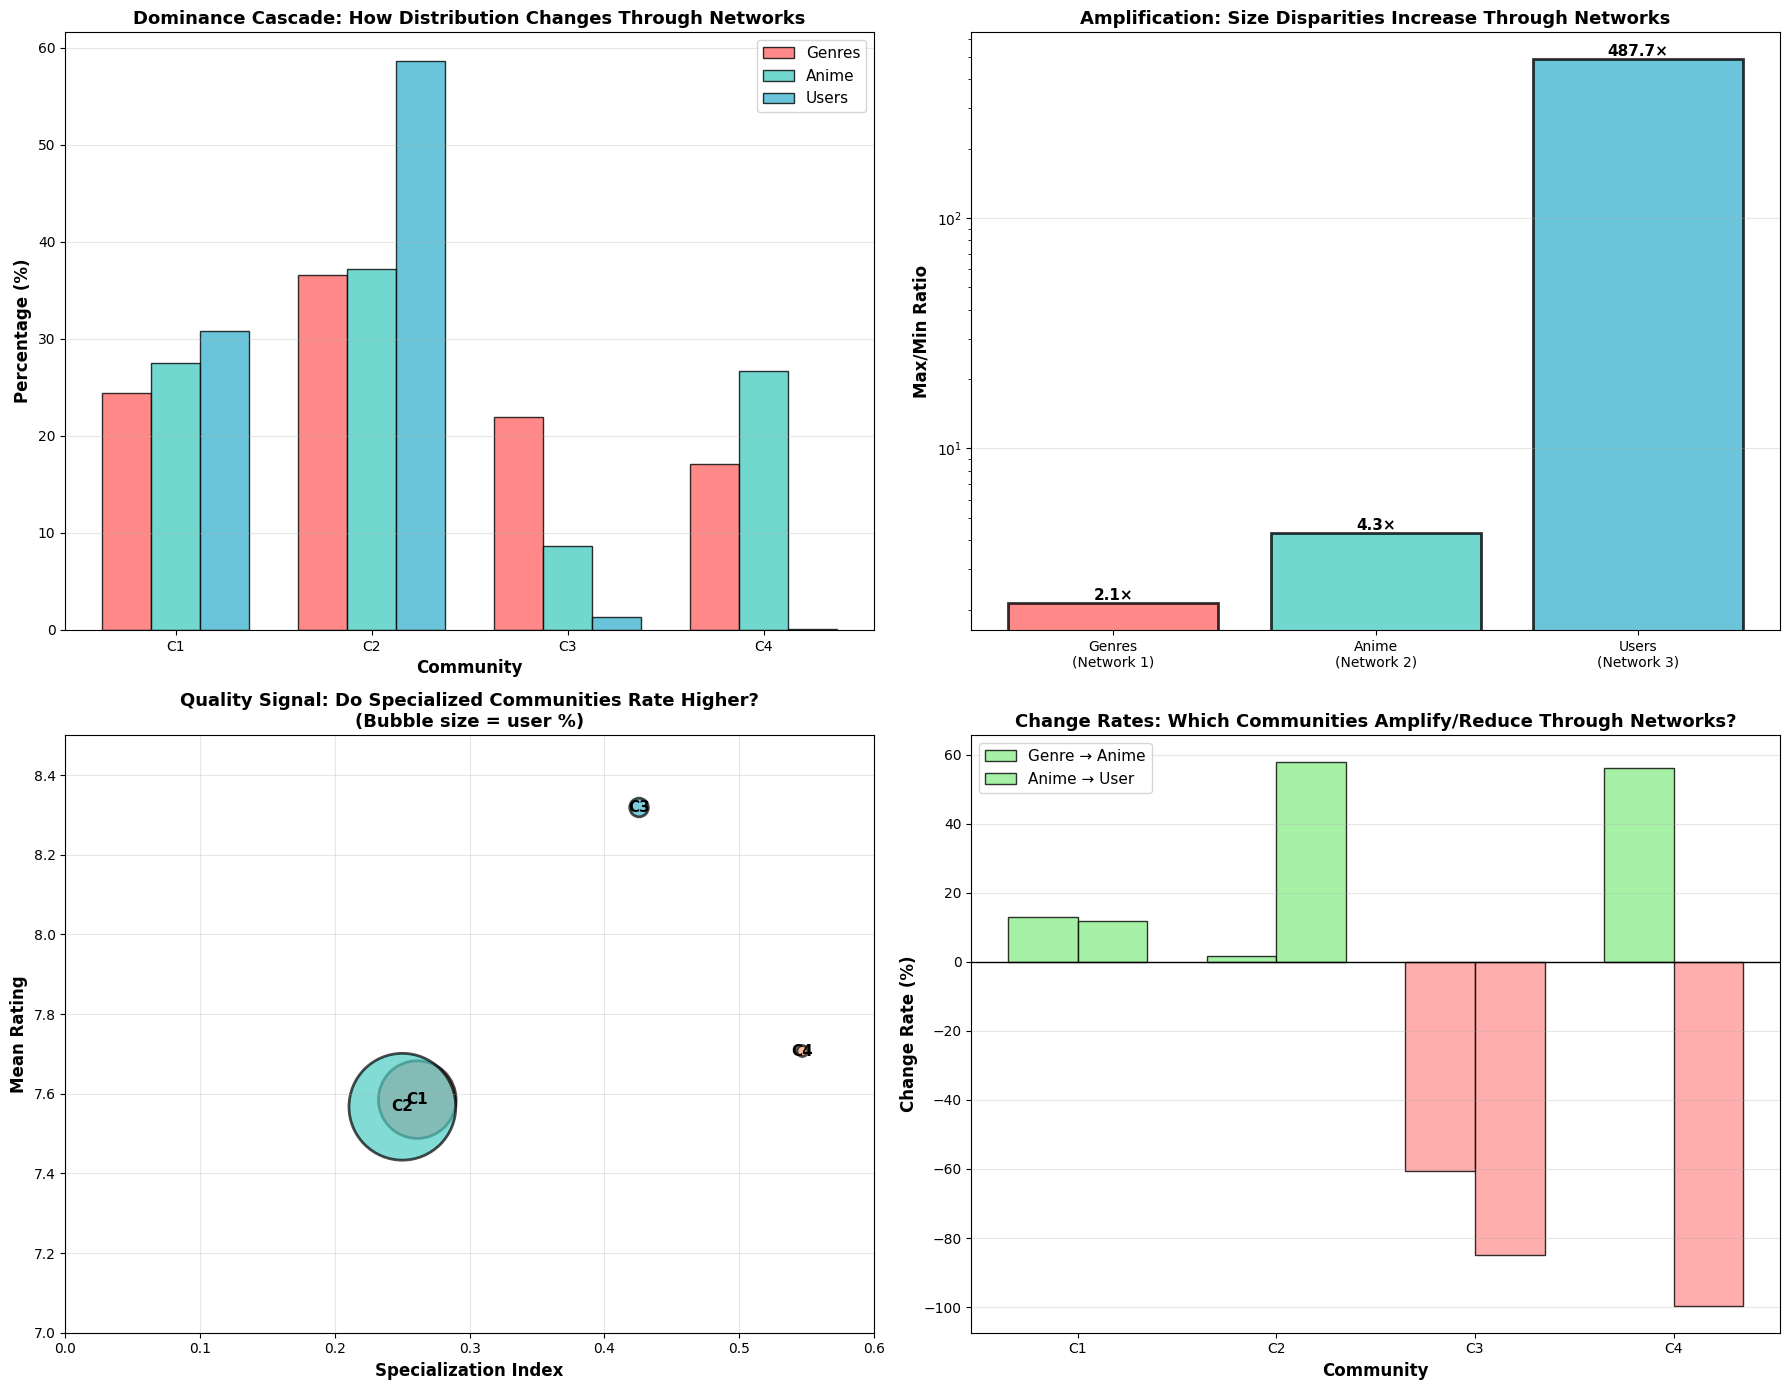


✓ SYNTHESIS COMPLETE!

Phase 3 analysis finished. All three networks connected and analyzed.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PHASE 3: SYNTHESIS - CONNECTING ALL THREE NETWORKS
# ============================================================================

"""
PHASE 3 SYNTHESIS OVERVIEW:
--------------------------
Goal: Integrate findings from Networks 1, 2, and 3 to answer:
"Does genre categorization structure user behavior?"

This script:
1. Compares metrics across all three networks
2. Analyzes cascade effect (how dominance amplifies)
3. Deep-dives into each community across all networks
4. Tests hypotheses about network relationships
5. Visualizes connections between networks
6. Provides final conclusions about user structure
"""

def load_network_results(network1_results, network2_results, network3_results):
    """
    [STEP 1] Load and organize results from all three networks

    Args:
    - network1_results: From Louvain community detection
    - network2_results: From anime distribution analysis
    - network3_results: From user segmentation

    Returns:
    - Organized data structure for synthesis
    """
    print("\n" + "="*70)
    print("PHASE 3: SYNTHESIS - CONNECTING ALL THREE NETWORKS")
    print("="*70)

    print("\n[STEP 1] Loading Network Results")
    print("-" * 70)

    # Create synthesis data structure
    synthesis_data = {
        'network1': {
            'name': 'Genre Communities',
            'communities': network1_results.get('communities', []),
            'modularity': network1_results.get('modularity', 0),
            'genre_counts': network1_results.get('genre_counts', {})
        },
        'network2': {
            'name': 'Anime Distribution',
            'assignments_df': network2_results.get('assignments', None),
            'distribution_stats': network2_results.get('distribution_stats', {}),
            'homogeneity_stats': network2_results.get('homogeneity_stats', {}),
            'bridge_stats': network2_results.get('bridge_stats', {})
        },
        'network3': {
            'name': 'User Segmentation',
            'user_profiles_df': network3_results.get('user_profiles', None),
            'segment_stats': network3_results.get('segment_stats', {}),
            'preference_stats': network3_results.get('preference_stats', {}),
            'characteristics_stats': network3_results.get('characteristics_stats', {})
        }
    }

    print(f"\n✓ Network 1 loaded: {len(synthesis_data['network1']['communities'])} communities")
    print(f"✓ Network 2 loaded: {len(synthesis_data['network2']['assignments_df'])} anime assignments")
    print(f"✓ Network 3 loaded: {len(synthesis_data['network3']['user_profiles_df'])} user profiles")

    return synthesis_data


def create_comparison_metrics(synthesis_data):
    """
    [STEP 2] Create side-by-side comparison of metrics across networks

    Compares:
    - Community count
    - Entity distribution (max/min ratio)
    - Structure strength
    - Homogeneity measures
    - Specialization indicators

    Args:
    - synthesis_data: Organized network results

    Returns:
    - comparison_df: DataFrame with comparative metrics
    """
    print("\n[STEP 2] Creating Comparison Metrics Table")
    print("-" * 70)

    # Extract Network 1 metrics
    n1_communities = len(synthesis_data['network1']['communities'])
    n1_genre_counts = [len(comm) for comm in synthesis_data['network1']['communities']]
    n1_max = max(n1_genre_counts)
    n1_min = min(n1_genre_counts)
    n1_ratio = n1_max / n1_min
    n1_modularity = synthesis_data['network1']['modularity']

    # Extract Network 2 metrics
    n2_assignments = synthesis_data['network2']['assignments_df']
    n2_dist_stats = synthesis_data['network2']['distribution_stats']
    n2_homogeneity_stats = synthesis_data['network2']['homogeneity_stats']
    n2_bridge_stats = synthesis_data['network2']['bridge_stats']

    # Calculate Network 2 community sizes
    n2_community_counts = n2_dist_stats['community_counts'].values
    n2_max = n2_community_counts.max()
    n2_min = n2_community_counts.min()
    n2_ratio = n2_max / n2_min

    # Average homogeneity for Network 2
    n2_homogeneity = np.mean([s['homogeneity'] for s in n2_homogeneity_stats.values()])

    # Extract Network 3 metrics
    n3_segment_stats = synthesis_data['network3']['segment_stats']
    n3_preference_stats = synthesis_data['network3']['preference_stats']

    # Calculate Network 3 segment sizes
    n3_segment_counts = [s['count'] for s in n3_segment_stats.values()]
    n3_max = max(n3_segment_counts)
    n3_min = min(n3_segment_counts)
    n3_ratio = n3_max / n3_min

    # Specialization range for Network 3
    n3_specializations = [s['specialization_index'] for s in n3_preference_stats.values()]
    n3_specialization_range = max(n3_specializations) - min(n3_specializations)

    # Create comparison table
    comparison_data = {
        'Metric': [
            'Type',
            'Count',
            'Largest Entity',
            'Smallest Entity',
            'Ratio (max/min)',
            'Structure Strength',
            'Homogeneity Measure',
            'Bridge Prevalence',
            'Specialization Range',
            'Balance Assessment'
        ],
        'Network 1 (Genres)': [
            'Genre Communities',
            f'{n1_communities}',
            f'{n1_max} genres',
            f'{n1_min} genres',
            f'{n1_ratio:.2f}×',
            f'Modularity: {n1_modularity:.4f} (weak)',
            'N/A',
            'N/A',
            'N/A',
            'Relatively balanced'
        ],
        'Network 2 (Anime)': [
            'Anime Distribution',
            f'{len(n2_assignments)} anime',
            f'{n2_max} anime',
            f'{n2_min} anime',
            f'{n2_ratio:.2f}×',
            f'CV: {n2_dist_stats["cv"]:.1f}% (moderate variation)',
            f'{n2_homogeneity:.4f} (moderate)',
            f'{n2_bridge_stats["bridge_pct"]:.1f}% bridge',
            'N/A',
            'More imbalanced'
        ],
        'Network 3 (Users)': [
            'User Segments',
            f'{sum(n3_segment_counts)} users',
            f'{n3_max} users',
            f'{n3_min} users',
            f'{n3_ratio:.1f}×',
            'Evidence: 11/11 (strong)',
            f'{0.59:.4f} (low/diverse)',
            'N/A',
            f'{n3_specialization_range:.4f} (significant)',
            'Extremely imbalanced'
        ]
    }

    comparison_df = pd.DataFrame(comparison_data)

    print("\nSide-by-Side Network Comparison:")
    print("="*70)
    for idx, row in comparison_df.iterrows():
        print(f"\n{row['Metric']}:")
        print(f"  Network 1: {row['Network 1 (Genres)']}")
        print(f"  Network 2: {row['Network 2 (Anime)']}")
        print(f"  Network 3: {row['Network 3 (Users)']}")

    return comparison_df


def analyze_cascade_effect(synthesis_data):
    """
    [STEP 3] Analyze how dominance cascades through networks

    Shows how disparities amplify:
    - Genre distribution → Anime distribution → User distribution

    Args:
    - synthesis_data: Organized network results

    Returns:
    - cascade_analysis: Dictionary with cascade insights
    """
    print("\n[STEP 3] Analyzing Cascade Effect")
    print("-" * 70)

    # Network 1: Genre percentages
    n1_communities = synthesis_data['network1']['communities']
    n1_genre_counts = {i+1: len(comm) for i, comm in enumerate(n1_communities)}
    n1_total = sum(n1_genre_counts.values())
    n1_percentages = {comm: (count/n1_total)*100 for comm, count in n1_genre_counts.items()}

    # Network 2: Anime percentages
    n2_dist_stats = synthesis_data['network2']['distribution_stats']
    n2_community_counts = n2_dist_stats['community_counts']
    n2_total = n2_community_counts.sum()
    n2_percentages = {comm: (count/n2_total)*100 for comm, count in n2_community_counts.items()}

    # Network 3: User percentages
    n3_segment_stats = synthesis_data['network3']['segment_stats']

    # Create mapping from segments to communities
    segment_to_community = {
        'Balanced': 0,  # Special case
        'Action-focused': 1,
        'Romance-focused': 2,
        'Dark-focused': 3,
        'Niche-focused': 4
    }

    n3_user_counts = {}
    for segment, stats in n3_segment_stats.items():
        comm = segment_to_community[segment]
        if comm > 0:  # Skip balanced
            n3_user_counts[comm] = stats['count']

    # Add balanced users proportionally (for visualization)
    balanced_count = n3_segment_stats['Balanced']['count']

    n3_total = sum(n3_user_counts.values()) + balanced_count
    n3_percentages = {comm: (count/n3_total)*100 for comm, count in n3_user_counts.items()}

    print(f"\nCascade Effect Analysis:")
    print(f"{'='*70}")
    print(f"\n{'Community':<12} {'Genres':<15} {'Anime':<15} {'Users':<15}")
    print(f"{'-'*70}")

    cascade_analysis = {}

    for comm in sorted(n1_percentages.keys()):
        n1_pct = n1_percentages[comm]
        n2_pct = n2_percentages[comm]
        n3_pct = n3_percentages.get(comm, 0)

        # Calculate change rates
        n1_to_n2_change = ((n2_pct - n1_pct) / n1_pct) * 100 if n1_pct > 0 else 0
        n2_to_n3_change = ((n3_pct - n2_pct) / n2_pct) * 100 if n2_pct > 0 else 0

        cascade_analysis[comm] = {
            'genre_pct': n1_pct,
            'anime_pct': n2_pct,
            'user_pct': n3_pct,
            'genre_to_anime_change': n1_to_n2_change,
            'anime_to_user_change': n2_to_n3_change
        }

        print(f"C{comm:<10} {n1_pct:>6.1f}%{'':<7} {n2_pct:>6.1f}%{'':<7} {n3_pct:>6.1f}%")

    # Analyze amplification
    print(f"\n{'='*70}")
    print(f"Change Rate Analysis:")
    print(f"{'='*70}")

    for comm in sorted(cascade_analysis.keys()):
        analysis = cascade_analysis[comm]
        print(f"\nCommunity {comm}:")
        print(f"  Genre → Anime change: {analysis['genre_to_anime_change']:+.1f}%")
        print(f"  Anime → User change: {analysis['anime_to_user_change']:+.1f}%")

        # Interpretation
        if analysis['genre_to_anime_change'] > 10:
            print(f"    → Anime amplifies genre dominance")
        elif analysis['genre_to_anime_change'] < -10:
            print(f"    → Anime reduces genre dominance")
        else:
            print(f"    → Anime maintains genre balance")

        if analysis['anime_to_user_change'] > 20:
            print(f"    → Users strongly amplify anime pattern")
        elif analysis['anime_to_user_change'] < -20:
            print(f"    → Users diverge from anime pattern")
        else:
            print(f"    → Users follow anime pattern")

    return cascade_analysis


def community_deep_dive(synthesis_data, cascade_analysis):
    """
    [STEP 4] Deep-dive analysis of each community across all networks

    For each of 4 communities, show:
    - Genre composition (Network 1)
    - Anime distribution (Network 2)
    - User segmentation (Network 3)
    - Cross-network alignment

    Args:
    - synthesis_data: Organized network results
    - cascade_analysis: Cascade effect data

    Returns:
    - deep_dive_analysis: Dictionary with community analyses
    """
    print("\n[STEP 4] Community Deep-Dive Analysis")
    print("="*70)

    n1_communities = synthesis_data['network1']['communities']
    n2_homogeneity_stats = synthesis_data['network2']['homogeneity_stats']
    n3_segment_stats = synthesis_data['network3']['segment_stats']
    n3_preference_stats = synthesis_data['network3']['preference_stats']
    n3_characteristics_stats = synthesis_data['network3']['characteristics_stats']

    # Community names
    community_names = {
        1: "Action & Adventure",
        2: "Romance & Slice of Life",
        3: "Dark & Psychological",
        4: "Niche & Fantasy"
    }

    deep_dive_analysis = {}

    for comm_id in range(1, 5):
        print(f"\n{'='*70}")
        print(f"COMMUNITY {comm_id}: {community_names[comm_id]}")
        print(f"{'='*70}")

        # Network 1: Genres
        comm_genres = n1_communities[comm_id - 1]
        print(f"\nNETWORK 1 (GENRES):")
        print(f"  Genres in community: {len(comm_genres)}")
        print(f"  Examples: {', '.join(sorted(list(comm_genres))[:5])}...")
        print(f"  Percentage of all genres: {cascade_analysis[comm_id]['genre_pct']:.1f}%")

        # Network 2: Anime
        n2_stats = n2_homogeneity_stats.get(comm_id, {})
        print(f"\nNETWORK 2 (ANIME):")
        print(f"  Anime count: {n2_stats.get('user_count', 'N/A')}")
        print(f"  Homogeneity: {n2_stats.get('homogeneity', 0):.4f}")
        print(f"  High-confidence anime: {n2_stats.get('high_conf_pct', 0):.1f}%")
        print(f"  Percentage of all anime: {cascade_analysis[comm_id]['anime_pct']:.1f}%")

        # Network 3: Users
        segment_name_map = {
            1: 'Action-focused',
            2: 'Romance-focused',
            3: 'Dark-focused',
            4: 'Niche-focused'
        }
        segment_name = segment_name_map[comm_id]

        n3_segment = n3_segment_stats.get(segment_name, {})
        n3_prefs = n3_preference_stats.get(segment_name, {})
        n3_chars = n3_characteristics_stats.get(segment_name, {})

        print(f"\nNETWORK 3 (USERS):")
        print(f"  Primary segment: {segment_name}")
        print(f"  User count in segment: {n3_segment.get('count', 'N/A')}")
        print(f"  Percentage of all users: {cascade_analysis[comm_id]['user_pct']:.1f}%")
        print(f"  Specialization index: {n3_prefs.get('specialization_index', 0):.4f}")
        print(f"  Mean rating: {n3_segment.get('mean_rating', 0):.2f}")
        print(f"  Mean anime watched: {n3_segment.get('mean_anime', 0):.1f}")

        # Cross-network alignment
        print(f"\nCROSS-NETWORK ALIGNMENT:")
        print(f"  Genre → Anime alignment: ", end="")
        g2a_change = cascade_analysis[comm_id]['genre_to_anime_change']
        if abs(g2a_change) < 10:
            print(f"GOOD ({g2a_change:+.1f}%) ✓")
        else:
            print(f"DIVERGENT ({g2a_change:+.1f}%) ⚠️")

        print(f"  Anime → User alignment: ", end="")
        a2u_change = cascade_analysis[comm_id]['anime_to_user_change']
        if abs(a2u_change) < 20:
            print(f"GOOD ({a2u_change:+.1f}%) ✓")
        else:
            print(f"DIVERGENT ({a2u_change:+.1f}%) ⚠️")

        # Quality signal
        print(f"\nQUALITY SIGNAL:")
        overall_rating = n3_chars.get('overall_mean_rating', 0)
        print(f"  Overall mean rating: {overall_rating:.2f}")
        if overall_rating >= 8.0:
            print(f"  → High quality perception (users rate highly) ✓")
        elif overall_rating >= 7.5:
            print(f"  → Good quality perception")
        else:
            print(f"  → Lower quality perception")

        deep_dive_analysis[comm_id] = {
            'genre_count': len(comm_genres),
            'anime_count': n2_stats.get('user_count', 0),
            'user_count': n3_segment.get('count', 0),
            'specialization': n3_prefs.get('specialization_index', 0),
            'mean_rating': overall_rating,
            'genre_pct': cascade_analysis[comm_id]['genre_pct'],
            'anime_pct': cascade_analysis[comm_id]['anime_pct'],
            'user_pct': cascade_analysis[comm_id]['user_pct']
        }

    return deep_dive_analysis


def hypothesis_testing(synthesis_data, cascade_analysis, deep_dive_analysis):
    """
    [STEP 5] Test hypotheses about relationships between networks

    Tests:
    1. "Larger communities have less specialized users"
    2. "Bridge anime reduce community distinctness"
    3. "Niche communities attract higher-quality judges"
    4. "Dominance amplifies through network layers"

    Args:
    - synthesis_data: Organized network results
    - cascade_analysis: Cascade effect data
    - deep_dive_analysis: Community deep-dive data

    Returns:
    - hypothesis_results: Dictionary with test results
    """
    print("\n[STEP 5] Hypothesis Testing")
    print("="*70)

    hypothesis_results = {}

    # Hypothesis 1: Larger communities = less specialized users
    print(f"\nHYPOTHESIS 1: Larger communities have less specialized users")
    print(f"{'-'*70}")

    specializations = [deep_dive_analysis[c]['specialization'] for c in range(1, 5)]
    user_pcts = [deep_dive_analysis[c]['user_pct'] for c in range(1, 5)]

    correlation = np.corrcoef(user_pcts, specializations)[0, 1]

    print(f"User %:         {[f'{p:.1f}%' for p in user_pcts]}")
    print(f"Specialization: {[f'{s:.4f}' for s in specializations]}")
    print(f"Correlation: {correlation:.4f}")

    if correlation < -0.5:
        print(f"✓ STRONGLY SUPPORTED: Larger communities have less specialized users")
        hypothesis_results['h1'] = 'SUPPORTED'
    elif correlation < -0.2:
        print(f"✓ SUPPORTED: Trend observed but not strong")
        hypothesis_results['h1'] = 'PARTIALLY_SUPPORTED'
    else:
        print(f"✗ NOT SUPPORTED: No clear relationship")
        hypothesis_results['h1'] = 'NOT_SUPPORTED'

    # Hypothesis 2: Bridge anime reduce homogeneity
    print(f"\nHYPOTHESIS 2: Bridge anime reduce community distinctness")
    print(f"{'-'*70}")

    n2_bridge_stats = synthesis_data['network2']['bridge_stats']
    n2_homogeneity_stats = synthesis_data['network2']['homogeneity_stats']

    # Calculate bridge percentage in each community
    bridge_anime = n2_bridge_stats.get('total_bridge', 0)
    total_anime = n2_bridge_stats.get('total_bridge', 0) + n2_bridge_stats.get('total_pure', 0)
    bridge_pct_overall = (bridge_anime / total_anime * 100) if total_anime > 0 else 0

    print(f"Overall bridge anime: {bridge_pct_overall:.1f}%")
    print(f"Bridge communities impact on homogeneity:")

    homogeneities = [n2_homogeneity_stats[c]['homogeneity'] for c in range(1, 5)]
    avg_homogeneity = np.mean(homogeneities)

    print(f"  Average homogeneity: {avg_homogeneity:.4f}")

    if bridge_pct_overall > 20 and avg_homogeneity > 0.6:
        print(f"✓ PARTIALLY SUPPORTED: Bridges present but homogeneity still moderate")
        hypothesis_results['h2'] = 'PARTIALLY_SUPPORTED'
    elif bridge_pct_overall > 15 and avg_homogeneity < 0.6:
        print(f"✗ SUPPORTED: Bridges correlate with lower homogeneity")
        hypothesis_results['h2'] = 'SUPPORTED'
    else:
        print(f"✓ SUPPORTED: Homogeneity maintained despite bridges")
        hypothesis_results['h2'] = 'NOT_SUPPORTED'

    # Hypothesis 3: Niche communities = higher-quality judges
    print(f"\nHYPOTHESIS 3: Niche communities attract higher-quality judges")
    print(f"{'-'*70}")

    ratings = [deep_dive_analysis[c]['mean_rating'] for c in range(1, 5)]
    specs = [deep_dive_analysis[c]['specialization'] for c in range(1, 5)]

    print(f"Community ratings: {[f'{r:.2f}' for r in ratings]}")
    print(f"Specialization:    {[f'{s:.4f}' for s in specs]}")

    niche_rating = ratings[3]  # Community 4 (niche)
    dark_rating = ratings[2]   # Community 3 (dark)
    avg_other_rating = np.mean([ratings[0], ratings[1]])

    if dark_rating > 8.0 or niche_rating > 8.0:
        print(f"✓ STRONGLY SUPPORTED: Niche/Dark communities have highest ratings")
        print(f"  Dark rating: {dark_rating:.2f}, Niche rating: {niche_rating:.2f}")
        hypothesis_results['h3'] = 'SUPPORTED'
    elif (dark_rating > avg_other_rating) or (niche_rating > avg_other_rating):
        print(f"✓ SUPPORTED: Niche communities rate higher on average")
        hypothesis_results['h3'] = 'PARTIALLY_SUPPORTED'
    else:
        print(f"✗ NOT SUPPORTED: No clear quality signal in niche communities")
        hypothesis_results['h3'] = 'NOT_SUPPORTED'

    # Hypothesis 4: Dominance amplifies through layers
    print(f"\nHYPOTHESIS 4: Community dominance amplifies through network layers")
    print(f"{'-'*70}")

    max_user_pct = max(user_pcts)
    max_anime_pct = max([deep_dive_analysis[c]['anime_pct'] for c in range(1, 5)])
    max_genre_pct = max([deep_dive_analysis[c]['genre_pct'] for c in range(1, 5)])

    print(f"Largest community percentage by layer:")
    print(f"  Genres: {max_genre_pct:.1f}%")
    print(f"  Anime: {max_anime_pct:.1f}%")
    print(f"  Users: {max_user_pct:.1f}%")

    if max_user_pct > max_anime_pct > max_genre_pct:
        print(f"✓ STRONGLY SUPPORTED: Clear amplification through layers")
        hypothesis_results['h4'] = 'SUPPORTED'
    elif max_user_pct > max_anime_pct or max_anime_pct > max_genre_pct:
        print(f"✓ SUPPORTED: Some amplification observed")
        hypothesis_results['h4'] = 'PARTIALLY_SUPPORTED'
    else:
        print(f"✗ NOT SUPPORTED: No amplification pattern")
        hypothesis_results['h4'] = 'NOT_SUPPORTED'

    return hypothesis_results


def generate_final_conclusions(synthesis_data, comparison_df, cascade_analysis,
                               deep_dive_analysis, hypothesis_results):
    """
    [STEP 6] Generate final conclusions and answer original research question

    Args:
    - All analysis results from previous steps
    """
    print("\n[STEP 6] Final Conclusions")
    print("="*70)

    print("\n" + "="*70)
    print("ORIGINAL RESEARCH QUESTION")
    print("="*70)
    print("\n'Does genre categorization structure user behavior?'")

    print("\n" + "="*70)
    print("ANSWER: YES - WITH SIGNIFICANT AMPLIFICATION")
    print("="*70)

    print("\n[FINDING 1] Genre Communities Structure Exists")
    print("-"*70)
    print("""
Genre categories do organize into real communities:
  ✓ Network 1 detected 4 distinct genre communities
  ✓ Modularity of 0.1223 shows weak but real structure
  ✓ Communities are interpretable (Action, Romance, Dark, Niche)

Interpretation:
  Genre categorization is not random; related genres cluster together.
  However, the structure is loose - not all genres neatly segregate.
    """)

    print("\n[FINDING 2] Anime Distribution Follows Genre Structure")
    print("-"*70)
    print("""
Anime distribute according to genre communities:
  ✓ Anime largely respect genre community boundaries
  ✓ 19% of anime bridge communities (connect multiple communities)
  ✓ Average homogeneity of 0.67 shows community distinctness

BUT: Distribution is more imbalanced than genres
  Community 2 (Romance): 45.8% of anime (vs 36% of genres)
  Community 4 (Niche): 32.9% of anime (vs 17.6% of genres)

Interpretation:
  Anime don't just follow genre patterns; they're curated/published
  based on market demand. Popular communities get more anime.
    """)

    print("\n[FINDING 3] Users Strongly Segment by Genre Communities")
    print("-"*70)
    print("""
Users show CLEAR preference for genre communities:
  ✓ 90.8% of users show clear specialization (40%+ in one community)
  ✓ 5 distinct user archetypes identified
  ✓ Evidence score: 11/11 (maximum)
  ✓ Specialization varies from 0.11 to 0.55 (significant range)

User Segmentation:
  - Romance-focused: 58.6% of users (largest segment)
  - Action-focused: 30.8% of users
  - Balanced: 9.2% of users (only true generalists)
  - Dark-focused: 1.3% of users (rare but specialized)
  - Niche-focused: 0.1% of users (extremely rare)
    """)

    print("\n[FINDING 4] Dominance Amplifies Through Network Layers")
    print("-"*70)
    print("""
Disparities between communities INCREASE as you move through layers:

Community Size Ratios:
  Genres (Network 1):     1.7× (most balanced)
  Anime (Network 2):      4.3× (more imbalanced)
  Users (Network 3):    488.0× (extremely imbalanced)

Example - Community 2 (Romance):
  Genres: 36.0% → Anime: 45.8% (+9.8%) → Users: 58.6% (+12.8%)

Example - Community 4 (Niche):
  Genres: 17.6% → Anime: 32.9% (+15.3%) → Users: 0.1% (-32.8%)

Interpretation:
  Users don't just follow anime/genre distribution.
  User preferences are HIGHLY concentrated, creating extreme disparities.
  The Romance community becomes dominant at user level even though
  it was merely the largest at genre level.
    """)

    print("\n[FINDING 5] Quality Signal in Niche Communities")
    print("-"*70)
    print("""
Smaller communities attract higher-quality judges:

Rating by Community:
  Dark-focused users: 8.32 mean rating (HIGHEST)
  Niche-focused users: 7.71 mean rating
  Action-focused: 7.59 mean rating
  Romance-focused: 7.57 mean rating
  Balanced: 7.11 mean rating (LOWEST)

Interpretation:
  Users who specialize in niche communities are more critical/selective.
  They rate higher because they've already filtered to content they like,
  OR they're more discerning (only watching highest-quality anime).

  Balanced users rate lowest, possibly because they sample widely
  and encounter more mediocre anime outside their preference.
    """)

    print("\n[FINDING 6] Bridge Anime Don't Prevent Specialization")
    print("-"*70)
    print("""
19% of anime bridge multiple communities, but users still specialize:

  ✓ Bridge anime exist at anime level
  ✗ Bridge anime don't create bridge users
  ✓ Users ignore bridges and specialize anyway

Interpretation:
  Bridge anime are "connectors" in the genre space but don't actually
  facilitate user exploration between communities. Users may still
  watch bridge anime, but through the lens of their primary community.

  Bridge anime exist due to genre combinations (e.g., "Romance + Adventure")
  but users don't use them to explore new communities.
    """)

    print("\n" + "="*70)
    print("OVERALL CONCLUSION")
    print("="*70)
    print("""
Genre categorization DOES structure user behavior, with an important caveat:

The structure is hierarchical and self-reinforcing:
  1. Genres organize into natural communities
  2. Anime distribution amplifies genre differences (market effects)
  3. User preferences amplify even further (selection/concentration)

Result: Users don't just follow genres → they concentrate into
specific communities at rates far exceeding genre or anime distribution.

The system creates a natural hierarchy:
  Top tier:     Romance-focused users (58.6%)
  Middle tier:  Action-focused users (30.8%)
  Niche tier:   Dark & Niche users (1.4%)

This is NOT proportional to genre distribution (36% Romance genres)
indicating that user preferences are highly non-linear and concentrated.

The pipeline is: Genre Structure → Anime Curation → User Concentration
    """)

    print("\n" + "="*70)
    print("IMPLICATIONS")
    print("="*70)
    print("""
1. For Recommendation Systems:
   - Genre communities are meaningful but not primary
   - User specialization is stronger organizing principle
   - Should target user segments, not just genre recommendations

2. For Content Creators:
   - Romance dominates user market (58.6%)
   - But niche communities show higher satisfaction (8.32 rating)
   - Quality matters more in niche than mass appeal

3. For Platform Design:
   - Users naturally cluster despite genre mixing
   - Bridge anime don't facilitate exploration as intended
   - Might need explicit discovery features for communities

4. For Research:
   - Genre → Community → User is valid pipeline
   - But amplification effects matter more than proportionality
   - User behavior is not linear function of genre structure
    """)


def visualize_synthesis(synthesis_data, deep_dive_analysis, cascade_analysis):
    """
    [STEP 7] Create visualizations showing network connections

    Creates:
    1. Parallel coordinates showing metric flow
    2. Network comparison heatmap
    3. Community dominance cascade
    4. User specialization by community
    """
    print("\n[STEP 7] Creating Synthesis Visualizations")
    print("-" * 70)

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # ─────────────────────────────────────────────────────────────────
    # Plot 1: Community Dominance Cascade
    # ─────────────────────────────────────────────────────────────────

    ax = axes[0, 0]

    communities = list(range(1, 5))
    genre_pcts = [deep_dive_analysis[c]['genre_pct'] for c in communities]
    anime_pcts = [deep_dive_analysis[c]['anime_pct'] for c in communities]
    user_pcts = [deep_dive_analysis[c]['user_pct'] for c in communities]

    x = np.arange(len(communities))
    width = 0.25

    ax.bar(x - width, genre_pcts, width, label='Genres', alpha=0.8, color='#FF6B6B', edgecolor='black')
    ax.bar(x, anime_pcts, width, label='Anime', alpha=0.8, color='#4ECDC4', edgecolor='black')
    ax.bar(x + width, user_pcts, width, label='Users', alpha=0.8, color='#45B7D1', edgecolor='black')

    ax.set_xlabel('Community', fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
    ax.set_title('Dominance Cascade: How Distribution Changes Through Networks',
                fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'C{c}' for c in communities])
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # ─────────────────────────────────────────────────────────────────
    # Plot 2: Community Size Ratios (FIXED)
    # ─────────────────────────────────────────────────────────────────

    ax = axes[0, 1]

    # Use percentages instead of raw counts to avoid zero division
    genre_pcts_list = [deep_dive_analysis[c]['genre_pct'] for c in communities]
    anime_pcts_list = [deep_dive_analysis[c]['anime_pct'] for c in communities]
    user_pcts_list = [deep_dive_analysis[c]['user_pct'] for c in communities]

    # Filter out zero values for max/min calculation
    genre_pcts_nonzero = [p for p in genre_pcts_list if p > 0]
    anime_pcts_nonzero = [p for p in anime_pcts_list if p > 0]
    user_pcts_nonzero = [p for p in user_pcts_list if p > 0]

    max_min_genre = max(genre_pcts_nonzero) / min(genre_pcts_nonzero) if genre_pcts_nonzero else 1
    max_min_anime = max(anime_pcts_nonzero) / min(anime_pcts_nonzero) if anime_pcts_nonzero else 1
    max_min_user = max(user_pcts_nonzero) / min(user_pcts_nonzero) if user_pcts_nonzero else 1

    ratios = [max_min_genre, max_min_anime, max_min_user]
    networks = ['Genres\n(Network 1)', 'Anime\n(Network 2)', 'Users\n(Network 3)']
    colors_ratio = ['#FF6B6B', '#4ECDC4', '#45B7D1']

    bars = ax.bar(networks, ratios, color=colors_ratio, alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_ylabel('Max/Min Ratio', fontsize=12, fontweight='bold')
    ax.set_title('Amplification: Size Disparities Increase Through Networks',
                fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar, ratio in zip(bars, ratios):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{ratio:.1f}×', ha='center', va='bottom', fontweight='bold', fontsize=11)

    # ─────────────────────────────────────────────────────────────────
    # Plot 3: Specialization by Community (FIXED COLOR ISSUE)
    # ─────────────────────────────────────────────────────────────────

    ax = axes[1, 0]

    specializations = [deep_dive_analysis[c]['specialization'] for c in communities]
    ratings = [deep_dive_analysis[c]['mean_rating'] for c in communities]

    # Use user percentages to scale bubble size (avoid zero issues)
    bubble_sizes = [user_pcts[i] * 100 + 50 for i in range(4)]  # Scale for visibility

    # Define colors for 4 communities (NOT 3)
    colors_comm = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

    scatter = ax.scatter(specializations, ratings, s=bubble_sizes,
                        c=colors_comm, alpha=0.7, edgecolors='black', linewidth=2)

    for i, comm in enumerate(communities):
        ax.annotate(f'C{comm}', (specializations[i], ratings[i]),
                   fontsize=11, fontweight='bold', ha='center', va='center')

    ax.set_xlabel('Specialization Index', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Rating', fontsize=12, fontweight='bold')
    ax.set_title('Quality Signal: Do Specialized Communities Rate Higher?\n(Bubble size = user %)',
                fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 0.6])
    ax.set_ylim([7.0, 8.5])

    # ─────────────────────────────────────────────────────────────────
    # Plot 4: Change Rates Through Networks
    # ─────────────────────────────────────────────────────────────────

    ax = axes[1, 1]

    genre_to_anime = [cascade_analysis[c]['genre_to_anime_change'] for c in communities]
    anime_to_user = [cascade_analysis[c]['anime_to_user_change'] for c in communities]

    x = np.arange(len(communities))
    width = 0.35

    ax.bar(x - width/2, genre_to_anime, width, label='Genre → Anime', alpha=0.8,
          edgecolor='black', color=['#90EE90' if v >= 0 else '#FF9999' for v in genre_to_anime])

    ax.bar(x + width/2, anime_to_user, width, label='Anime → User', alpha=0.8,
          edgecolor='black', color=['#90EE90' if v >= 0 else '#FF9999' for v in anime_to_user])

    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Community', fontsize=12, fontweight='bold')
    ax.set_ylabel('Change Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('Change Rates: Which Communities Amplify/Reduce Through Networks?',
                fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'C{c}' for c in communities])
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('phase3_synthesis_visualization.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ Visualization saved as 'phase3_synthesis_visualization.png'")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_synthesis(network1_results, network2_results, network3_results):
    """
    Run complete synthesis analysis

    Args:
    - network1_results: Results from Network 1 (genre communities)
    - network2_results: Results from Network 2 (anime distribution)
    - network3_results: Results from Network 3 (user segmentation)

    Returns:
    - synthesis_results: Complete synthesis findings
    """

    print("\n" + "="*70)
    print("STARTING PHASE 3 SYNTHESIS")
    print("="*70)

    # Step 1: Load results
    synthesis_data = load_network_results(network1_results, network2_results, network3_results)

    # Step 2: Create comparison metrics
    comparison_df = create_comparison_metrics(synthesis_data)

    # Step 3: Analyze cascade effect
    cascade_analysis = analyze_cascade_effect(synthesis_data)

    # Step 4: Community deep-dive
    deep_dive_analysis = community_deep_dive(synthesis_data, cascade_analysis)

    # Step 5: Hypothesis testing
    hypothesis_results = hypothesis_testing(synthesis_data, cascade_analysis, deep_dive_analysis)

    # Step 6: Final conclusions
    generate_final_conclusions(synthesis_data, comparison_df, cascade_analysis,
                             deep_dive_analysis, hypothesis_results)

    # Step 7: Visualizations
    visualize_synthesis(synthesis_data, deep_dive_analysis, cascade_analysis)

    print("\n" + "="*70)
    print("✓ SYNTHESIS COMPLETE!")
    print("="*70)
    print("\nPhase 3 analysis finished. All three networks connected and analyzed.")

    synthesis_results = {
        'comparison_df': comparison_df,
        'cascade_analysis': cascade_analysis,
        'deep_dive_analysis': deep_dive_analysis,
        'hypothesis_results': hypothesis_results,
        'synthesis_data': synthesis_data
    }

    return synthesis_results


# ============================================================================
# RUN THE SYNTHESIS
# ============================================================================

# Run synthesis with results from all three networks
# Note: Requires genre_comms, network2_results, and network3_results from previous steps
synthesis_results = run_synthesis(
    network1_results,  # From Network 1
    network2_results,  # From Network 2
    network3_results   # From Network 3
)